# MEGARA astrometric reconstruction and spectral coaddition with 3DCubeGen

This notebook provides a complete worked workflow for reconstructing and astrometrically aligning the three MEGARA configurations used for **NGC 985**, followed by their spectral coaddition into a final cube. **Note that the OB05 of MR-G has 165 seconds of exposure time** and we discard it at the end of the astrometric correction, the same for the **OB01 of LR-B** that has problems with the fiber extraction.

The processing order is:

1. **LR-R** — reconstruct and determine its astrometric solution.
2. **MR-G** — reconstruct with the additional rotation and X-axis stretch required to match the SDSS astrometry.
3. **LR-B** — reconstruct and determine its astrometric solution.
4. **Coaddition** — combine `LR-B`, `MR-G`, and `LR-R` with `coad_cube`.

The individual sections preserve the iterative alignment procedure of the original notebooks: reconstruct an observation, reproject the external imaging with `crop_image`, measure the residual with `astromatch`, refine the offsets, align the individual RSS observations, and finally reconstruct the science cube.

> **Coordinate convention**
>
> A FITS cube loaded into NumPy is indexed as `(wavelength, y, x)`, whereas Astropy WCS routines use pixel coordinates `(x, y)`. This distinction is important whenever array indices are converted to or from sky coordinates.


## Contents

- [Part I — LR-R reconstruction and astrometric alignment](#Part-I-—-LR-R-reconstruction-and-astrometric-alignment)
- [Part II — MR-G reconstruction and astrometric alignment](#Part-II-—-MR-G-reconstruction-and-astrometric-alignment)
- [Part III — LR-B reconstruction and astrometric alignment](#Part-III-—-LR-B-reconstruction-and-astrometric-alignment)
- [Part IV — Spectral coaddition](#Part-IV-—-Spectral-coaddition-of-LR-B,-MR-G,-and-LR-R)


## Common requirements

The examples use the MEGARA reconstruction and cube utilities distributed with 3DCubeGen. The input directory is expected to contain the reduced RSS products and the SDSS reference images used by the original notebooks.

The numerical astrometric corrections in this tutorial are specific to the NGC 985 dataset. For a different target or observing sequence, determine new offsets with `astromatch` rather than copying these values directly.


In [1]:
import CubeGen.cubetools.cube_tools as ctools
import CubeGen.megaratools.megcubegen as mgcube
import CubeGen.megaratools.megmapgen as mgmap

from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

## Common paths and target

Change these values first when adapting the notebook to another dataset. The three original notebooks use the same directory for the reduced RSS files, reconstructed products, and astrometric comparison products.


In [2]:
dir1 = 'MEGARA/NGC985/'
dir2 = 'MEGARA/NGC985/'
dir3 = 'MEGARA/NGC985/'

name = 'NGC985'

# External SDSS images used as the astrometric reference.
sdss_images = [
    "frame-i-001869-2-0089",
    "frame-r-001869-2-0089",
    "frame-g-001869-2-0089",
]

# Part I — LR-R reconstruction and astrometric alignment

LR-R is processed first. In the original LR-R notebook the string `'LR-R'` was repeated throughout the reconstruction calls and filenames. Here it is defined once through `vph`, matching the convention already used by the MR-G and LR-B notebooks.

For this setup no additional rotation or spatial stretch is applied: `dtheta_ipa = 0` and the default spatial scale is retained.


In [3]:
vph = 'LR-R'
dtheta_ipa = 0.0
scfx = 1.0

reduxdir = dir1

## 3. Initial cube reconstruction

We first reconstruct the MEGARA observation without applying any
astrometric correction.

The reconstructed cube is generated with a spatial sampling of
0.35 arcsec per pixel and a Gaussian reconstruction kernel.

At this stage, the resulting cube retains the astrometric solution
derived from the original observation.

`dtheta_ipa` is the PA ofset to use, generally it is zero.

In [4]:
reduxdir=dir1
reduxL=['RSSOB1'+vph]

Processing NGC985
Using WCS and IPA to correct the fiber positions


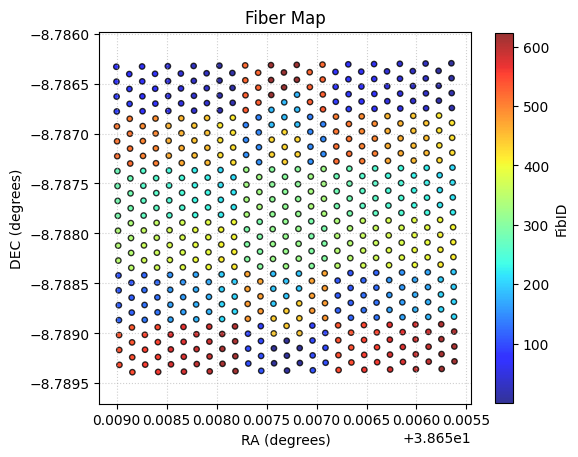

In [5]:
mgcube.megmap_ifu(reduxL,nameF=name+'A',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',verbose=True)

## 4. Reproject external imaging onto the IFU grid

External broad-band images are reprojected onto the spatial coordinate
system of the reconstructed MEGARA cube using `crop_image`.

For this example, SDSS-like `i`, `r`, and `g` images are used:

- `i` -> red channel
- `r` -> green channel
- `g` -> blue channel

The output FITS image has the same spatial WCS and pixel grid as the
reconstructed MEGARA cube. An RGB JPEG representation is also produced.

In [6]:
file='megCube-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

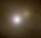

In [7]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

## 5. Measure the astrometric offset

The astrometric registration is evaluated with `astromatch`.

The function:

1. collapses each cube/image along its first axis,
2. fits a 2D PSF to determine the centroid,
3. converts the centroid of the reference cube to sky coordinates,
4. projects that sky position onto the second image,
5. computes the difference between the measured and expected positions.

The relevant residuals are the WCS-based offsets in the second pair of
reported values.

A residual close to zero indicates that the source centroid is consistent
with the WCS registration.

MEGARA/NGC985/megCube-NGC985A_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC985A_LR-R_gri.fits


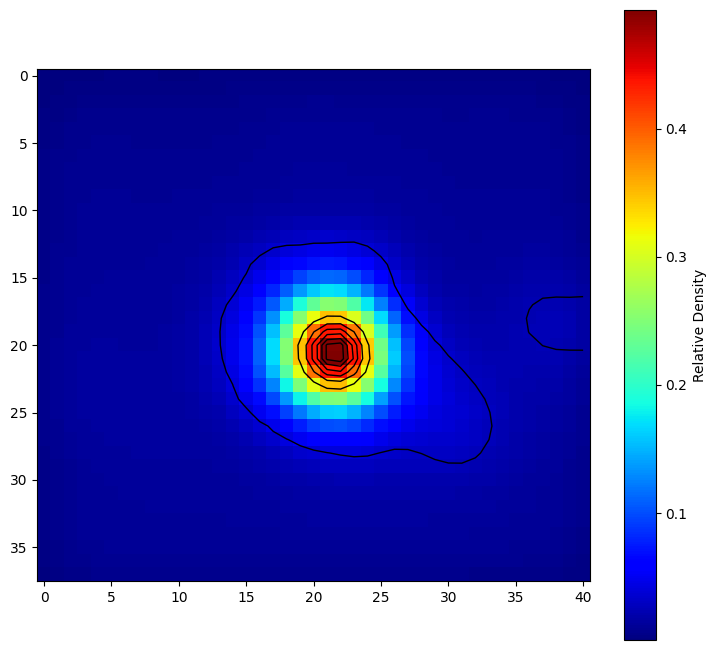

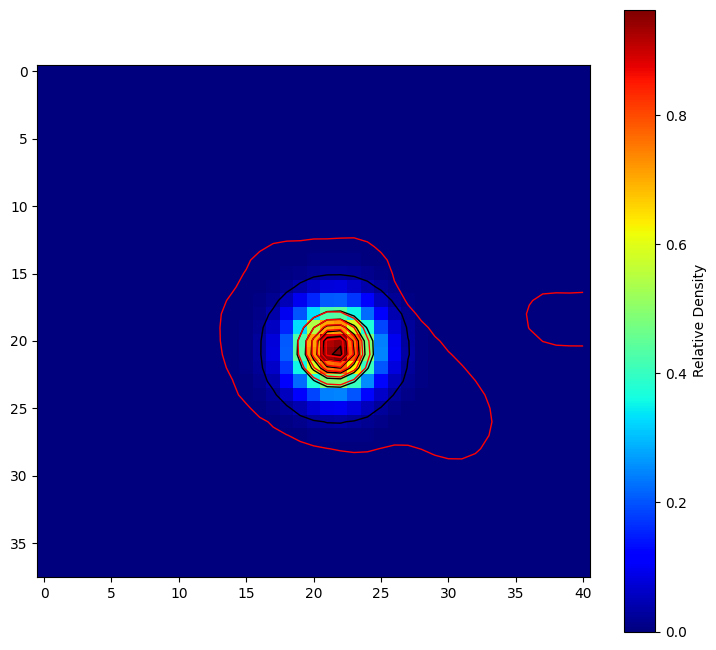

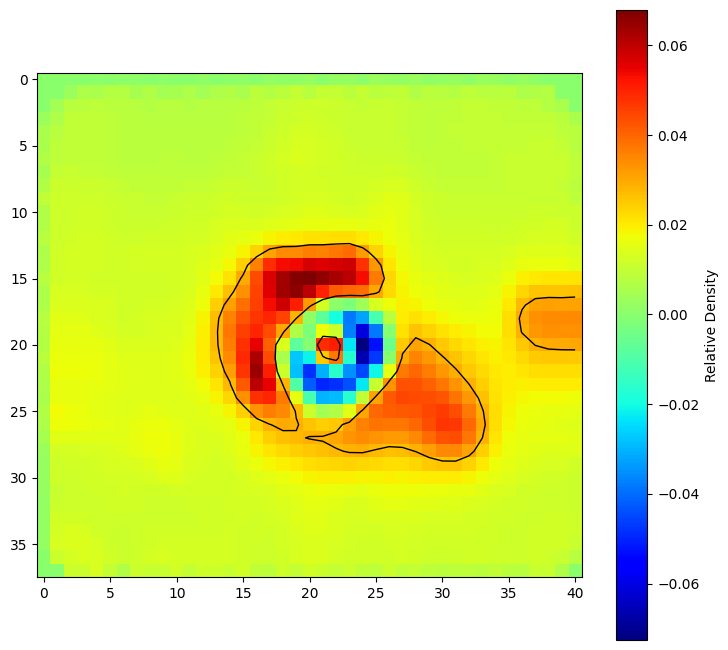

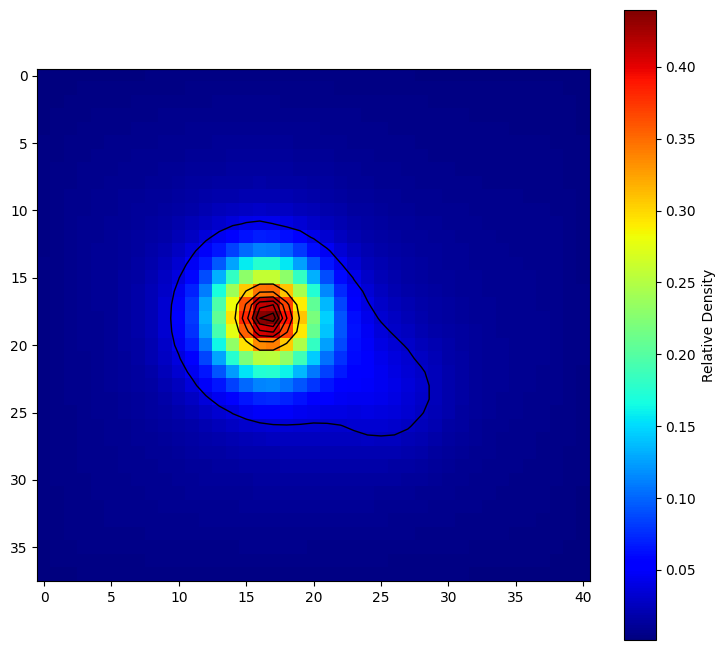

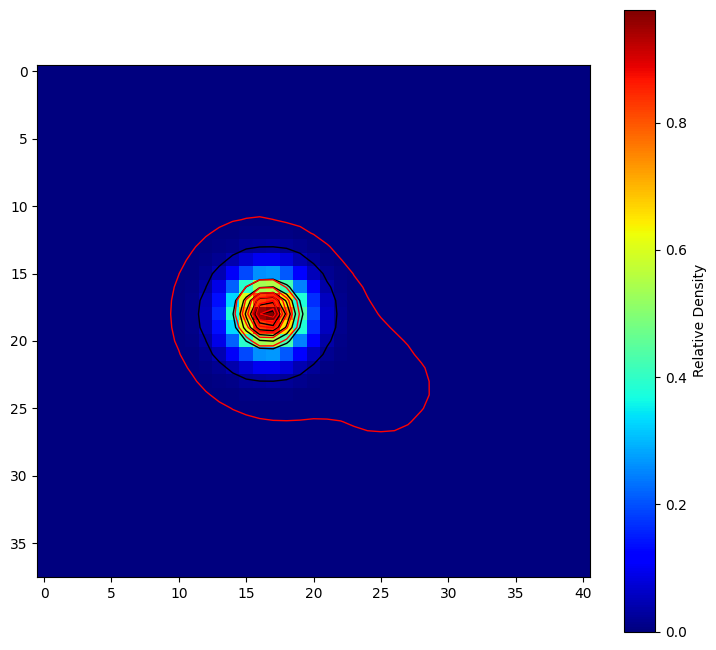

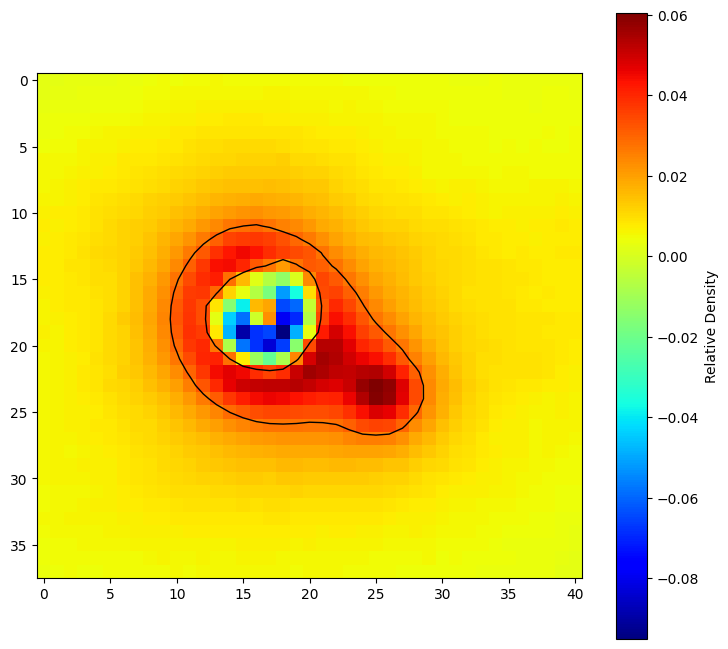

x_0= 21.6 y_0= 20.6 sigma_0= 2.05 psf_0= 3.1812935190301204
x_1= 16.6 y_1= 18.0 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.72193139s -08d47m15.10656949s RA0,DEC0
02h34m37.83998385s -08d47m16.01656931s RA1,DEC1
x_1_sk= 21.60000000000094 y_1_sk= 20.600000000080954
Dx= 5.0 -5.000000000000938
Dy= 2.6000000000000014 -2.6000000000809536


In [8]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Initial offset

For the first reconstruction, the measured centroid displacement is

- approximately 5.0 pixels in X,
- approximately 2.6 pixels in Y.

This indicates that an astrometric correction is required before combining
or comparing the reconstructed MEGARA data with the external imaging.

## 6. Apply the first astrometric correction

The measured displacement is supplied to the reconstruction through
`dxpix` and `dypix`.

These parameters shift the individual RSS contribution before generating
the reconstructed cube or map.

After applying the correction, the reconstructed product is generated
again and compared with the reference imaging.

In [9]:
reduxdir=dir1
reduxL=['RSSOB1'+vph]
mgcube.megmap_ifu(reduxL,nameF=name+'A',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[5],dypix=[-2.6])

Processing NGC985


In [10]:
file='megCube-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

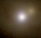

In [11]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

MEGARA/NGC985/megCube-NGC985A_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC985A_LR-R_gri.fits


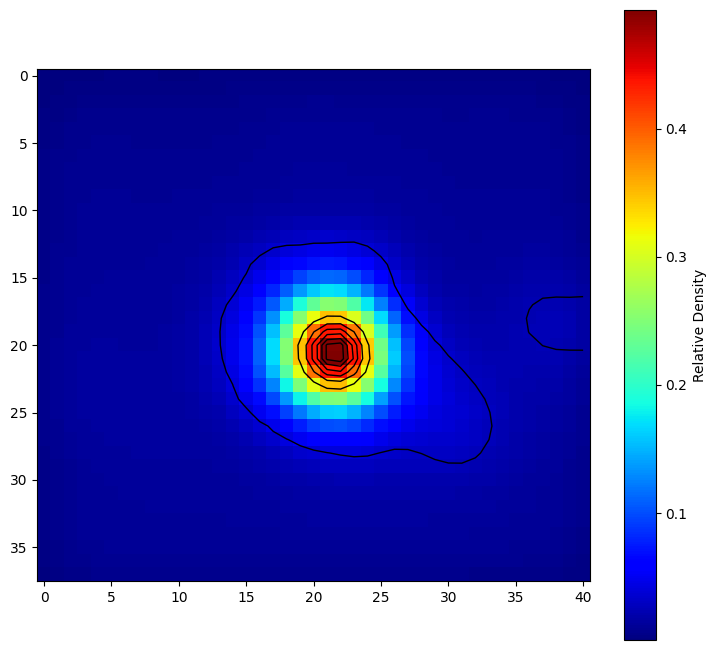

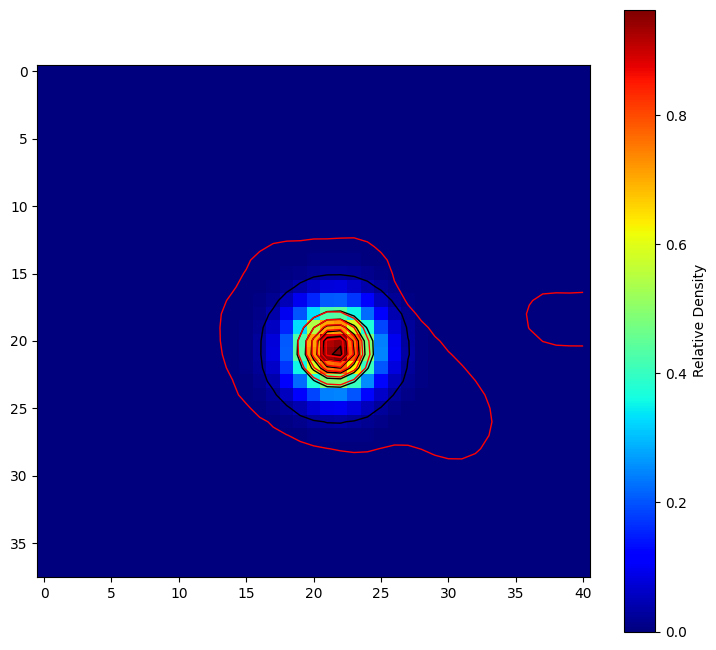

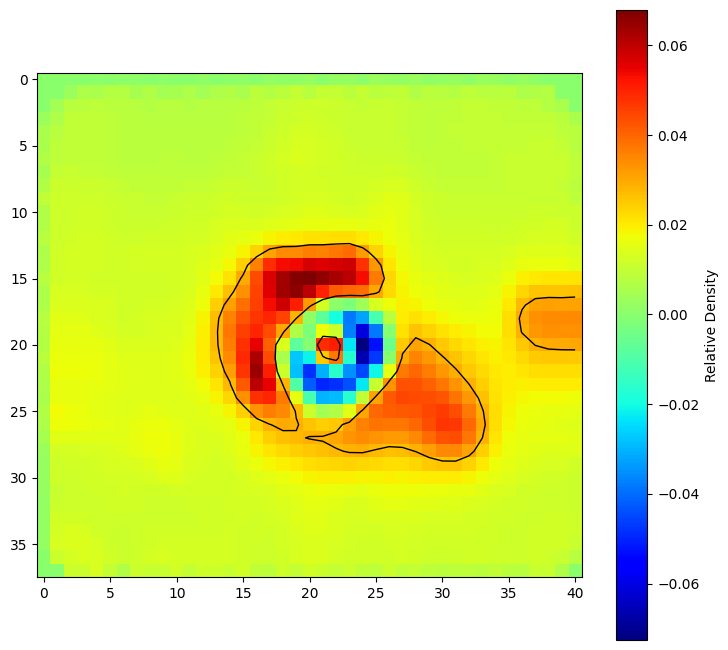

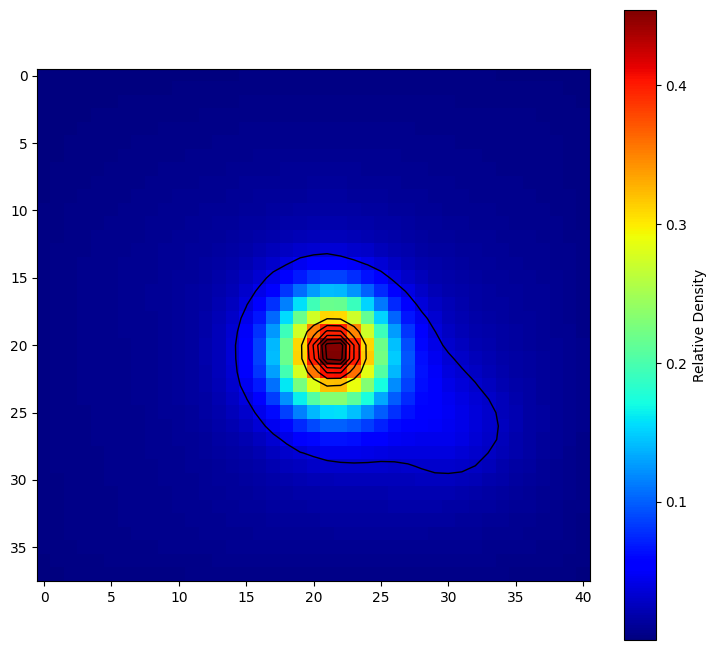

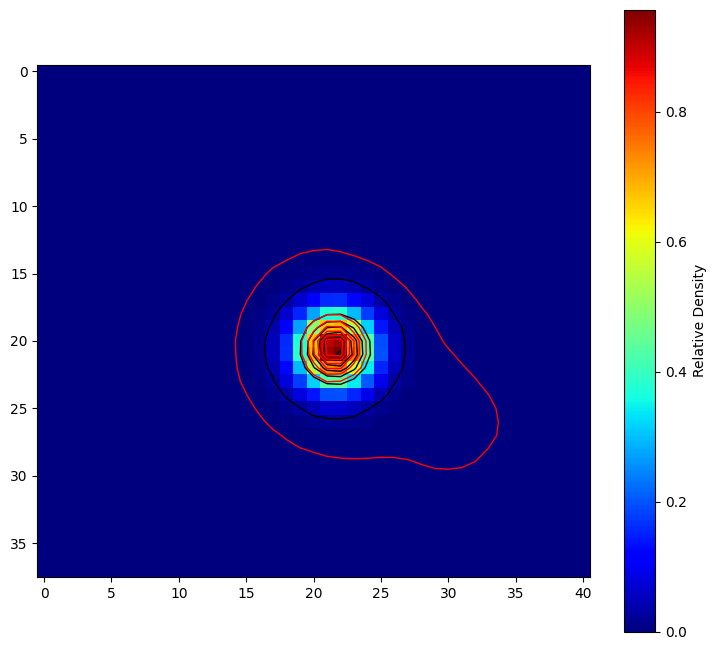

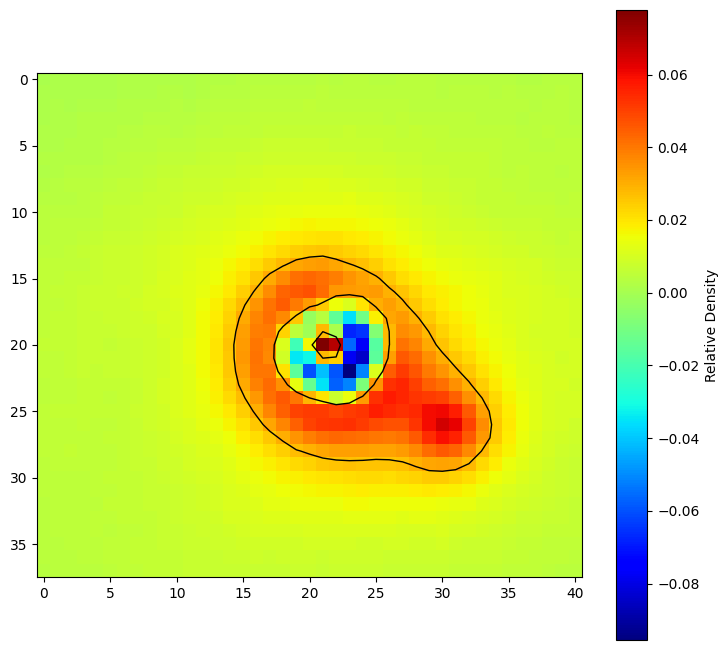

x_0= 21.6 y_0= 20.6 sigma_0= 2.05 psf_0= 3.1812935190301204
x_1= 21.6 y_1= 20.6 sigma_1= 1.9 psf_1= 2.948515944466941
02h34m37.83859803s -08d47m16.01656949s RA0,DEC0
02h34m37.83859803s -08d47m16.01656949s RA1,DEC1
x_1_sk= 21.600000000089295 y_1_sk= 20.599999999992598
Dx= 0.0 -8.929390560297179e-11
Dy= 0.0 7.403855306620244e-12


In [12]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Validation of the corrected cube

After applying the pixel correction, the measured centroids coincide.

The residual WCS offsets are of order `10^-11` pixels, which is effectively
zero at the numerical precision of the calculation.

This confirms that the corrected reconstruction is astrometrically aligned
with the reference imaging.

### Aplying to integrated 2D maps 

In [13]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'A_'+vph,errors=False,flu16=True,spec_range=(None,None),
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[5.4],dypix=[-1.2])

Processing NGC985


In [14]:
file='megMap-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


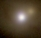

In [15]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [16]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC985A_LR-R.fits.gz
MEGARA/NGC985/megMap-NGC985A_LR-R_gri.fits
x_0= 21.2 y_0= 20.2 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 21.2 y_1= 20.2 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.84061576s -08d47m16.0584316s RA0,DEC0
02h34m37.84061576s -08d47m16.0584316s RA1,DEC1
x_1_sk= 21.199999999973926 y_1_sk= 20.200000000118607
Dx= 0.0 2.6073365688716876e-11
Dy= 0.0 -1.1860734616675472e-10


## 7. Align a second MEGARA observation

The same procedure is repeated for a second MEGARA RSS observation.

In [17]:
reduxdir=dir1
reduxL=['RSSOB5'+vph]

In [18]:
mgcube.megmap_ifu(reduxL,nameF=name+'B',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits')

Processing NGC985


In [19]:
file='megCube-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

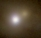

In [20]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

MEGARA/NGC985/megCube-NGC985B_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC985B_LR-R_gri.fits


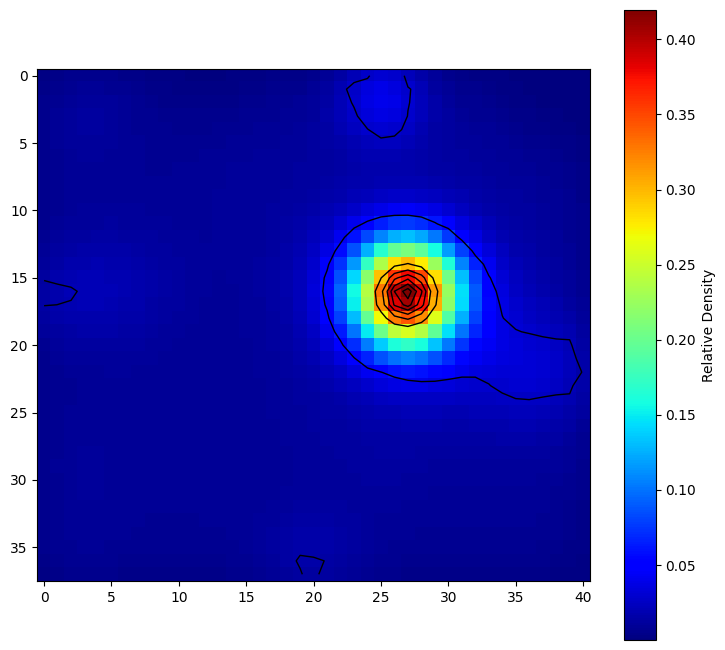

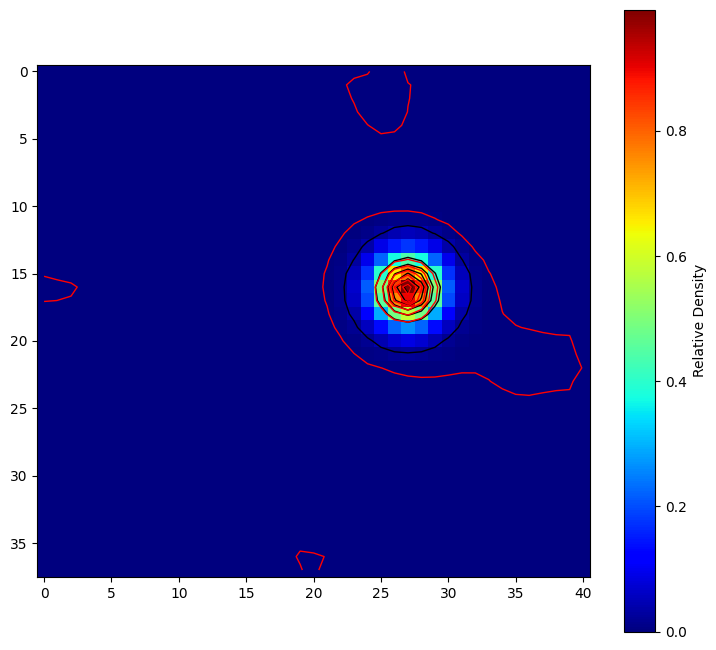

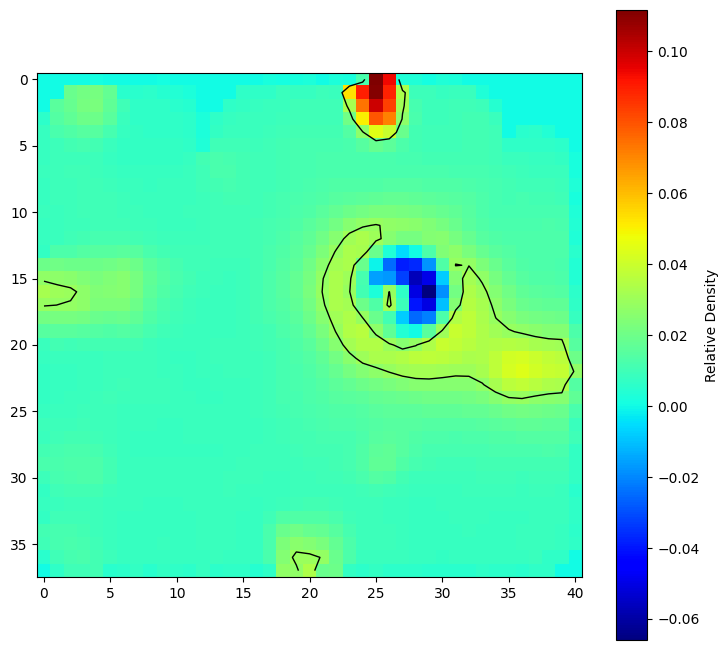

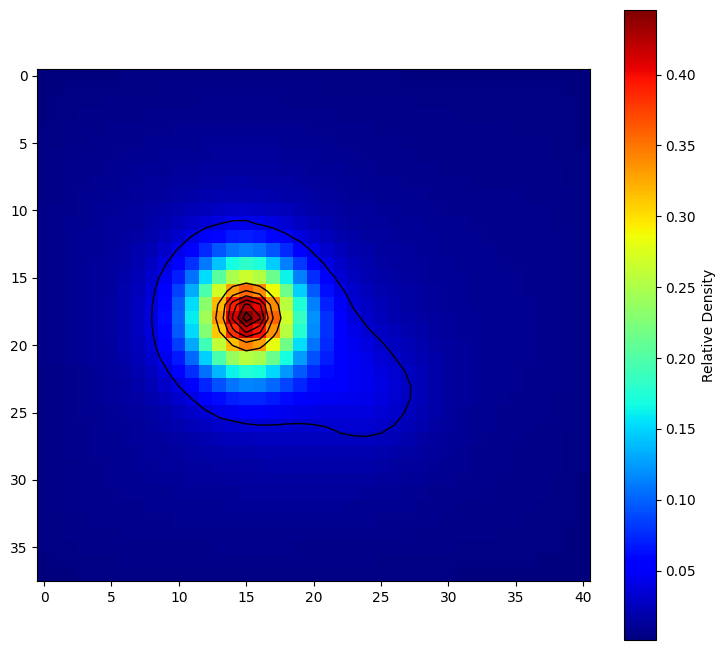

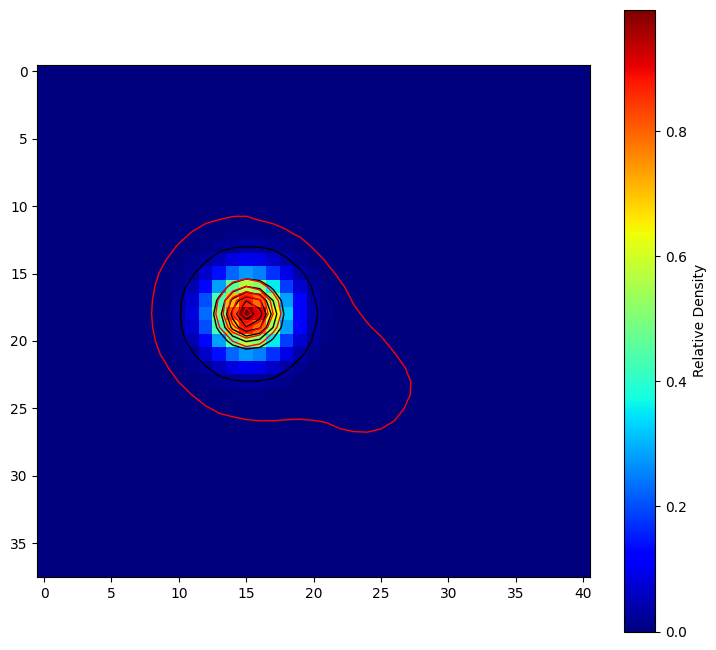

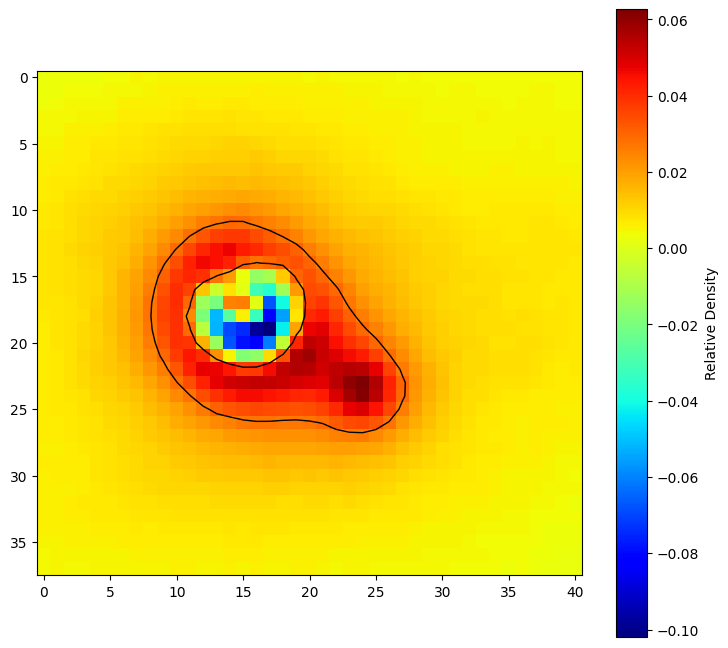

x_0= 27.0 y_0= 16.2 sigma_0= 1.72 psf_0= 2.6691828549911256
x_1= 15.2 y_1= 18.0 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.56082845s -08d47m16.64051925s RA0,DEC0
02h34m37.8394324s -08d47m16.01052098s RA1,DEC1
x_1_sk= 26.999999999950937 y_1_sk= 16.19999999996885
Dx= 11.8 -11.799999999950938
Dy= -1.8000000000000007 1.800000000031151


In [21]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Second image shifts
The uncorrected reconstruction shows a substantially larger displacement,
with an offset of approximately:

- 11.8 pixels in X,
- -1.8 pixel in Y.

These offsets are then incorporated into the reconstruction parameters.

In [22]:
mgcube.megmap_ifu(reduxL,nameF=name+'B',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[12],dypix=[1.8])

Processing NGC985


In [23]:
file='megCube-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

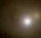

In [24]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [25]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985B_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC985B_LR-R_gri.fits
x_0= 27.0 y_0= 16.2 sigma_0= 1.72 psf_0= 2.6691828549911256
x_1= 27.0 y_1= 16.2 sigma_1= 1.84 psf_1= 2.8554049146416696
02h34m37.84082853s -08d47m16.01051925s RA0,DEC0
02h34m37.84082853s -08d47m16.01051925s RA1,DEC1
x_1_sk= 26.999999999916703 y_1_sk= 16.199999999857223
Dx= 0.0 8.329692491315654e-11
Dy= 0.0 1.4277645732363453e-10


### Validation of the second pointing

After applying the corresponding `dxpix` and `dypix` correction, the two
centroids agree to numerical precision.

This demonstrates that the same procedure can be independently applied to
multiple MEGARA observations before combining them.

### Aplying to integrated 2D maps 

Processing NGC985
Using WCS and IPA to correct the fiber positions


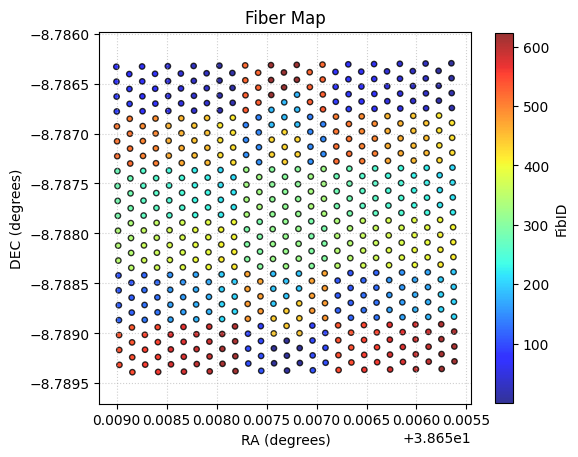

In [26]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'B_'+vph,errors=False,flu16=True,spec_range=(None,None),
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,verbose=True,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[11.4],dypix=[3.2])

In [27]:
file='megMap-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


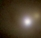

In [28]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [29]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC985B_LR-R.fits.gz
MEGARA/NGC985/megMap-NGC985B_LR-R_gri.fits
x_0= 27.2 y_0= 15.8 sigma_0= 1.72 psf_0= 2.6691828549911256
x_1= 27.2 y_1= 15.8 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.83893777s -08d47m16.0584736s RA0,DEC0
02h34m37.83893777s -08d47m16.0584736s RA1,DEC1
x_1_sk= 27.199999999976818 y_1_sk= 15.799999999955546
Dx= 0.0 2.318145675417327e-11
Dy= 0.0 4.445510626283067e-11


## 8. Relative registration between multiple observations

Once each observation has been individually aligned with the external
reference image, their relative registration must also be checked before
coaddition.

To isolate the contribution of each RSS observation, reconstructed maps
are generated separately using the `facT` parameter.

The resulting products are then compared with `astromatch`. To a quick analysis we use the MAP (`meggen_map`) function instead of the full CUBE data (`megmap_ifu`) 

In [30]:
reduxdir=dir1
reduxL=['RSSOB1'+vph,'RSSOB5'+vph]
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'1_'+vph,errors=False,flu16=True,spec_range=(None,None),
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[5,12],dypix=[-2.6,1.8],facT=[1,0])
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'2_'+vph,errors=False,flu16=True,spec_range=(None,None),
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[5,12],dypix=[-2.6,1.8],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [31]:
file='megMap-NAME1_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megMap-NAME2_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megMap-NGC9852_LR-R.fits.gz
x_0= 21.2 y_0= 20.0 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 34.2 y_1= 20.0 sigma_1= 1.75 psf_1= 2.7157383699037614
02h34m37.99557835s -08d47m16.54845388s RA0,DEC0
02h34m37.68864176s -08d47m16.54844827s RA1,DEC1
x_1_sk= 21.2000000000749 y_1_sk= 20.000000000003848
Dx= -13.000000000000004 12.999999999925102
Dy= 0.0 -3.8475889141409425e-12


### Relative offset between observations

The first comparison reveals an additional relative displacement between
the two reconstructed observations.

This residual offset is incorporated into the individual `dxpix` and
`dypix` corrections before the final combination.

## 9. Refine the relative registration

The relative offsets measured between the two observations are added to
the previous individual corrections.

New maps are generated and compared again.

After this refinement, the measured centroids agree to numerical
precision, indicating that the two MEGARA observations are now mutually
registered.

In [32]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'1_'+vph,errors=False,flu16=True,spec_range=(None,None),
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[5+13,12],dypix=[-2.6,1.8],facT=[1,0])
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'2_'+vph,errors=False,flu16=True,spec_range=(None,None),
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[5+13,12],dypix=[-2.6,1.8],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [33]:
file='megMap-NAME1_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megMap-NAME2_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megMap-NGC9852_LR-R.fits.gz
x_0= 27.2 y_0= 20.0 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 27.2 y_1= 20.0 sigma_1= 1.72 psf_1= 2.6691828549911256
02h34m37.99377672s -08d47m16.54845301s RA0,DEC0
02h34m37.99377672s -08d47m16.54845301s RA1,DEC1
x_1_sk= 27.199999999939337 y_1_sk= 19.999999999918966
Dx= 0.0 6.066258606551855e-11
Dy= 0.0 8.103384629976063e-11


## 10. Validate the registration in the reconstructed cubes

The alignment determined from the reconstructed maps is propagated to the
full spectral cubes.

Because the PSF centroid measured from the full cube can differ slightly
from that measured in the collapsed maps, an additional fine adjustment
may be required.

The two reconstructed cubes are therefore compared directly with
`astromatch`.

In [34]:
mgcube.megmap_ifu(reduxL,nameF=name+'1',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[5+13,12],dypix=[-2.6,1.8],facT=[1,0])
mgcube.megmap_ifu(reduxL,nameF=name+'2',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[5+13,12],dypix=[-2.6,1.8],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [35]:
file='megCube-NAME1_LR-R.fits.gz'.replace('NAME',name)
file0=dir2+file
file='megCube-NAME2_LR-R.fits.gz'.replace('NAME',name)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC9852_LR-R.fits.gz
x_0= 28.8 y_0= 20.4 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 26.6 y_1= 20.4 sigma_1= 1.78 psf_1= 2.7622938848163976
02h34m37.96777444s -08d47m16.01366224s RA0,DEC0
02h34m38.01971753s -08d47m16.01366319s RA1,DEC1
x_1_sk= 28.800000000036935 y_1_sk= 20.40000000002301
Dx= 2.1999999999999993 -2.2000000000369333
Dy= 0.0 -2.3010926497590845e-11


### Fine correction

A small additional correction is applied to the first observation to
remove the remaining relative displacement.

After rebuilding the cubes, the X centroid difference is reduced to approximately 1.8 pixels,
while the remaining Y residual is reduced to zero and is
negligible compared with the adopted spatial sampling.

In [36]:
mgcube.megmap_ifu(reduxL,nameF=name+'1',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[5+13-2.05,12],dypix=[-2.6,1.8],facT=[1,0])
mgcube.megmap_ifu(reduxL,nameF=name+'2',errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[5+13-2.05,12],dypix=[-2.6,1.8],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [37]:
file='megCube-NAME1_LR-R.fits.gz'.replace('NAME',name)
file0=dir2+file
file='megCube-NAME2_LR-R.fits.gz'.replace('NAME',name)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC9852_LR-R.fits.gz
x_0= 26.8 y_0= 20.4 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 26.8 y_1= 20.4 sigma_1= 1.78 psf_1= 2.7622938848163976
02h34m37.96746827s -08d47m16.01366273s RA0,DEC0
02h34m37.96746827s -08d47m16.01366273s RA1,DEC1
x_1_sk= 26.800000000182024 y_1_sk= 20.400000000069117
Dx= 0.0 -1.8202328533334367e-10
Dy= 0.0 -6.911804462106375e-11


## 11. Final combined cube

Once the individual observations are aligned, they are combined using

```python
facT=[1,1]
```

to include both RSS datasets in the final reconstructed cube.

The combined cube is then compared once more with the external imaging.
This final check ensures that the astrometric registration has been
preserved during the coaddition.

Processing NGC985
Using WCS and IPA to correct the fiber positions
Processing NGC985
Using WCS and IPA to correct the fiber positions


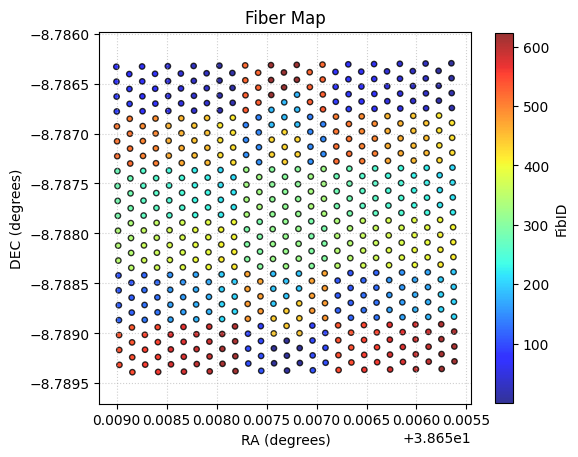

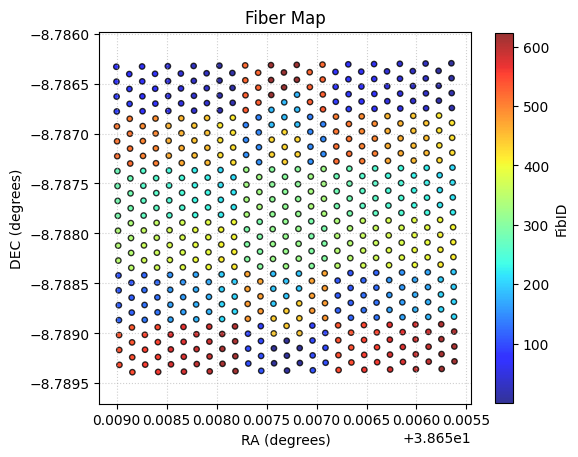

In [38]:
mgcube.megmap_ifu(reduxL,nameF=name,errors=False,flu16=True,spec_range=(None,None),headerInfo={},verbose=True,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[5+13-2.05,12],dypix=[-2.6,1.8],facT=[1,1])

In [39]:
file='megCube-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

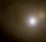

In [40]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [41]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC985_LR-R_gri.fits
x_0= 26.8 y_0= 20.4 sigma_0= 1.8699999999999999 psf_0= 2.901960429554305
x_1= 32.2 y_1= 20.4 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.96746827s -08d47m16.01366273s RA0,DEC0
02h34m37.83997158s -08d47m16.01365901s RA1,DEC1
x_1_sk= 26.800000000182024 y_1_sk= 20.400000000069117
Dx= -5.400000000000002 5.399999999817979
Dy= 0.0 -6.911804462106375e-11


### Global astrometric correction

Although the individual observations are internally aligned, the combined
cube may still exhibit a global displacement with respect to the external
reference frame.

For the combined reconstruction, a residual offset of approximately

- -5.4 pixels in X,
- 0.0 pixels in Y

is detected.

This global shift is corrected using the `dx` and `dy` parameters of the
reconstruction routine.

## 12. Final astrometric solution

The global correction is applied directly during the cube reconstruction:

```python
dx=-5.4
dy=0.05
```
After rebuilding the cube and reprojecting the reference imaging, the
measured centroids agree to numerical precision.

The final WCS residuals are approximately 10^-11 pixels, demonstrating
that the reconstructed MEGARA cube is astrometrically aligned with the
external imaging reference.

In [42]:
mgcube.megmap_ifu(reduxL,nameF=name,errors=False,flu16=True,spec_range=(None,None),headerInfo={},
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dtheta_ipa=dtheta_ipa,
    dxpix=[5+13-2.05,12],dypix=[-2.6,1.8],facT=[1,1],dx=-5.4,dy=0.05)

Processing NGC985
Processing NGC985


In [43]:
file='megCube-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

In [44]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC985_LR-R_gri.fits
x_0= 26.8 y_0= 20.4 sigma_0= 1.8699999999999999 psf_0= 2.901960429554305
x_1= 26.8 y_1= 20.4 sigma_1= 1.84 psf_1= 2.8554049146416696
02h34m37.83997158s -08d47m16.03115901s RA0,DEC0
02h34m37.83997158s -08d47m16.03115901s RA1,DEC1
x_1_sk= 26.800000000062674 y_1_sk= 20.399999999904626
Dx= 0.0 -6.267342200771964e-11
Dy= 0.0 9.537259870739945e-11


## 13. Final reconstructed 2D map

The same astrometric solution can be applied when generating a final
two-dimensional reconstructed map.

The resulting map is reprojected against the same external imaging and
validated with `astromatch`.

The final comparison again gives residuals consistent with zero, showing
that the astrometric solution is preserved in both the reconstructed
spectral cube and the derived 2D map.

In [45]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'_'+vph,errors=False,flu16=True,spec_range=(None,None),
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dtheta_ipa=dtheta_ipa,
    dxpix=[5+13,12],dypix=[-2.6,1.8],facT=[1,1],dx=-6.4,dy=-1.4)

Processing NGC985
Processing NGC985


In [46]:
file='megMap-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


In [47]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC985_LR-R.fits.gz
MEGARA/NGC985/megMap-NGC985_LR-R_gri.fits
x_0= 27.2 y_0= 20.0 sigma_0= 1.84 psf_0= 2.8554049146416696
x_1= 27.2 y_1= 20.0 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.84266958s -08d47m16.05844837s RA0,DEC0
02h34m37.84266958s -08d47m16.05844837s RA1,DEC1
x_1_sk= 27.20000000009999 y_1_sk= 20.000000000095437
Dx= 0.0 -9.99911264898401e-11
Dy= 0.0 -9.543654755361786e-11


## Summary

This notebook demonstrates an iterative astrometric alignment workflow for
MEGARA data reconstructed with 3DCubeGen.

The procedure can be summarized as:

1. Reconstruct each MEGARA observation.
2. Reproject external imaging onto the IFU spatial grid with `crop_image`.
3. Measure centroid offsets with `astromatch`.
4. Correct individual RSS positions using `dxpix` and `dypix`.
5. Verify the relative registration between multiple observations.
6. Apply any remaining global shift using `dx` and `dy`.
7. Reconstruct the final combined cube and map.
8. Validate the final astrometric solution against the external reference.

For NGC 985, the final reconstructed products reach astrometric residuals
consistent with zero at numerical precision.

> **Note**
>
> `dxpix` and `dypix` correct the relative position of individual RSS
> observations before their combination, whereas `dx` and `dy` apply a
> global shift to the final reconstructed coordinate grid.
>
> In practice, the alignment should therefore be performed in two stages:
> first the relative registration between exposures, and then the absolute
> registration against an external astrometric reference.

# Part II — MR-G reconstruction and astrometric alignment

The MR-G configuration requires an additional geometrical correction before the astrometric offsets are refined. The original analysis uses

```python
dtheta_ipa = 90 + 15.09
scfx = 1.3
```

Thus the reconstructed MR-G field is rotated by **105.09 degrees** and stretched along the X direction by a factor of **1.3**. These values are preserved exactly from the source notebook because they were introduced to bring the MEGARA reconstruction into agreement with the SDSS astrometric reference.

`dtheta_ipa` controls the rotation used during reconstruction, while `scfx` modifies the X spatial scale. They are geometrical corrections and are conceptually distinct from the translational corrections `dxpix`, `dypix`, `dx`, and `dy` determined later.

## 3. Initial cube reconstruction

We first reconstruct the MEGARA observation without applying any
astrometric correction.

The reconstructed cube is generated with a spatial sampling of
0.35 arcsec per pixel and a Gaussian reconstruction kernel.

At this stage, the resulting cube retains the astrometric solution
derived from the original observation.

`dtheta_ipa` is the PA ofset to use, generally it is zero.

In [48]:
dtheta_ipa=90+15.09
scfx=1.3

In [49]:
vph='MR-G'

In [50]:
reduxdir=dir1
reduxL=['RSSOB1'+vph]

Processing NGC985
Using WCS and IPA to correct the fiber positions


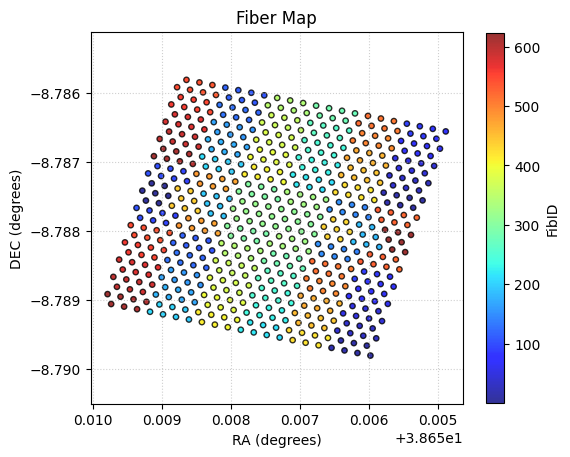

In [51]:
mgcube.megmap_ifu(reduxL,nameF=name+'A',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',verbose=True)

## 4. Reproject external imaging onto the IFU grid

External broad-band images are reprojected onto the spatial coordinate
system of the reconstructed MEGARA cube using `crop_image`.

For this example, SDSS-like `i`, `r`, and `g` images are used:

- `i` -> red channel
- `r` -> green channel
- `g` -> blue channel

The output FITS image has the same spatial WCS and pixel grid as the
reconstructed MEGARA cube. An RGB JPEG representation is also produced.

In [52]:
file='megCube-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

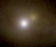

In [53]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

## 5. Measure the astrometric offset

The astrometric registration is evaluated with `astromatch`.

The function:

1. collapses each cube/image along its first axis,
2. fits a 2D PSF to determine the centroid,
3. converts the centroid of the reference cube to sky coordinates,
4. projects that sky position onto the second image,
5. computes the difference between the measured and expected positions.

The relevant residuals are the WCS-based offsets in the second pair of
reported values.

A residual close to zero indicates that the source centroid is consistent
with the WCS registration.

MEGARA/NGC985/megCube-NGC985A_MR-G.fits.gz
MEGARA/NGC985/megCube-NGC985A_MR-G_gri.fits


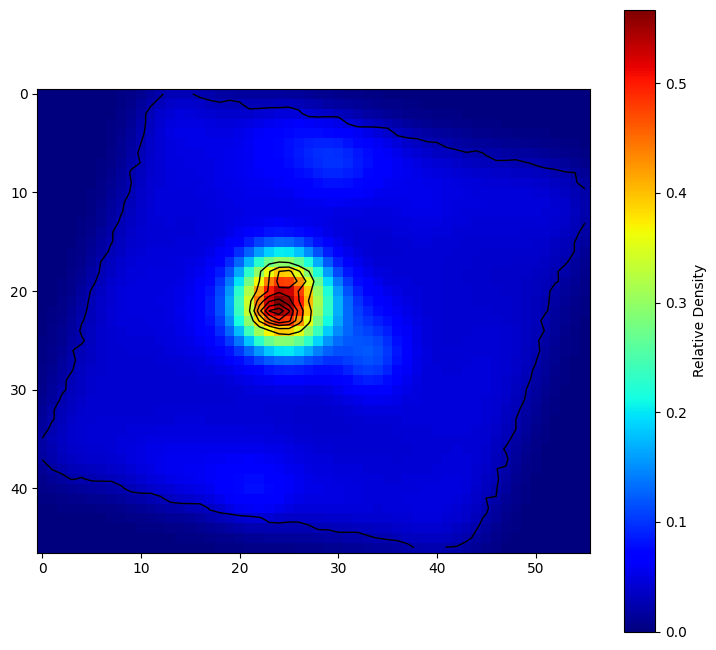

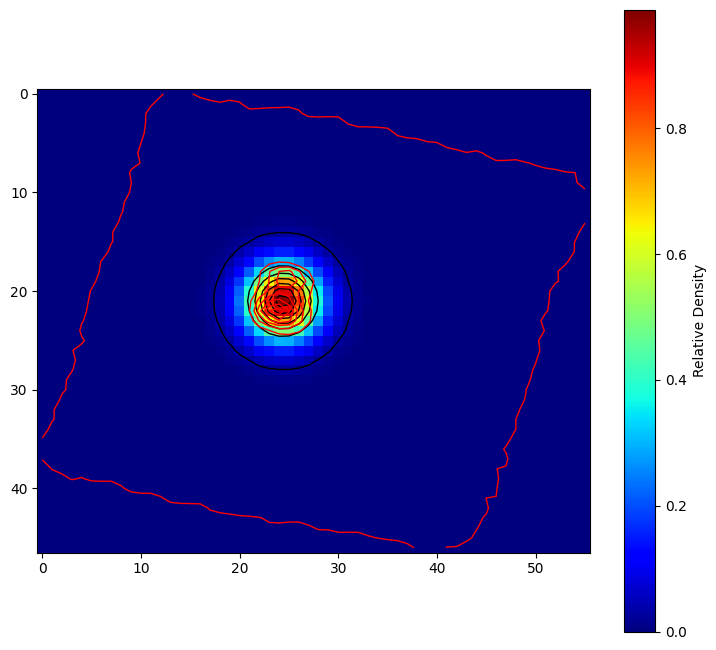

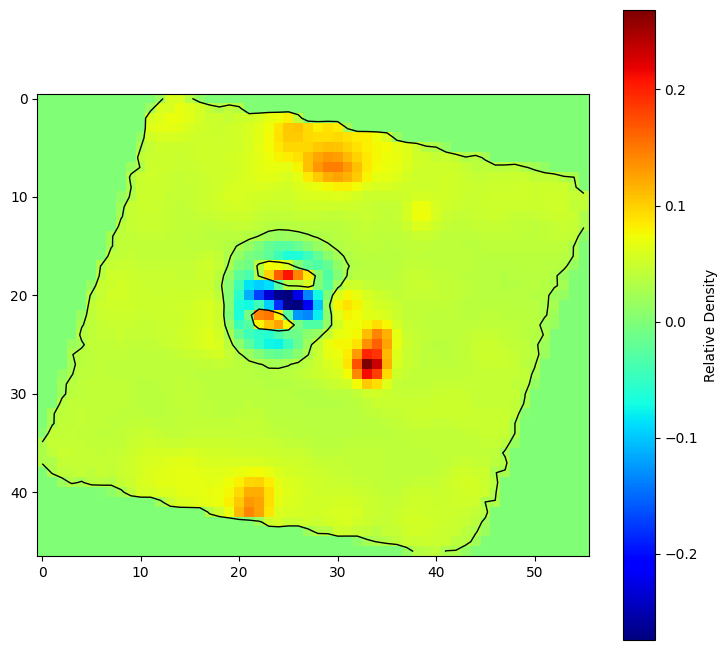

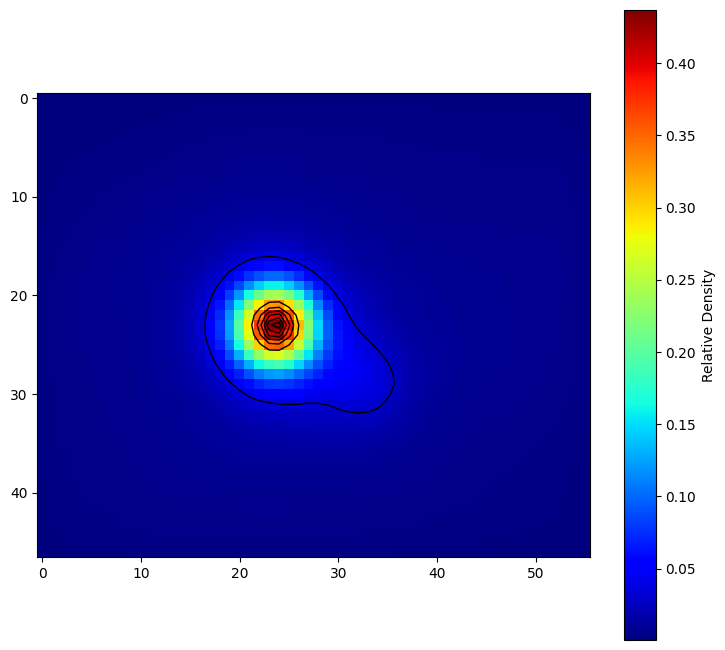

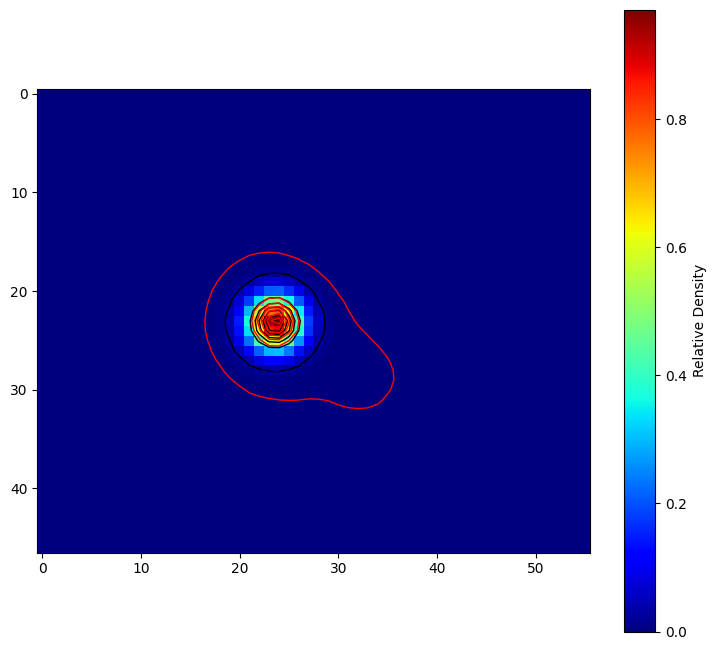

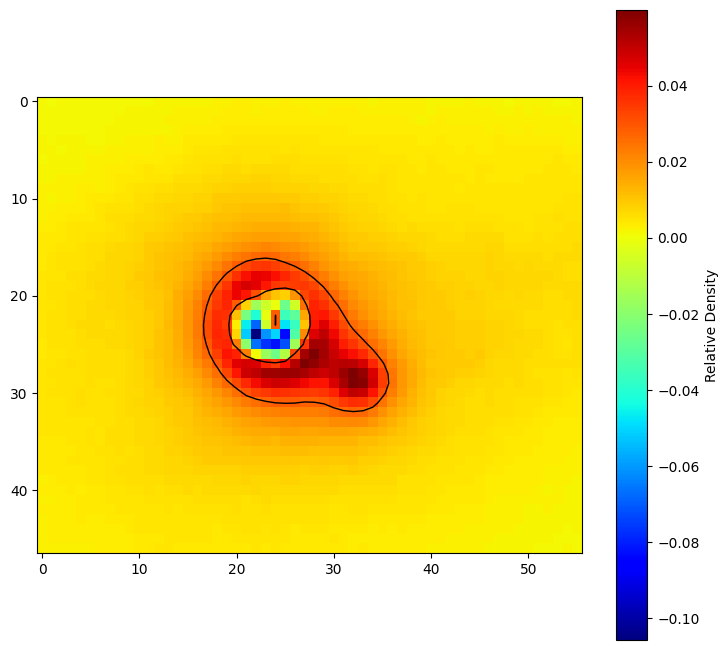

x_0= 24.4 y_0= 21.0 sigma_0= 2.59 psf_0= 4.019292787457567
x_1= 23.6 y_1= 23.2 sigma_1= 1.84 psf_1= 2.8554049146416696
02h34m37.82277478s -08d47m16.78640086s RA0,DEC0
02h34m37.84166314s -08d47m16.01640064s RA1,DEC1
x_1_sk= 24.39999999984423 y_1_sk= 20.99999999997773
Dx= 0.7999999999999972 -0.7999999998442284
Dy= -2.1999999999999993 2.2000000000222677


In [54]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Initial offset

For the first reconstruction, the measured centroid displacement is

- approximately 0.8 pixels in X,
- approximately -2.2 pixels in Y.

This indicates that an astrometric correction is required before combining
or comparing the reconstructed MEGARA data with the external imaging.

## 6. Apply the first astrometric correction

The measured displacement is supplied to the reconstruction through
`dxpix` and `dypix`.

These parameters shift the individual RSS contribution before generating
the reconstructed cube or map.

After applying the correction, the reconstructed product is generated
again and compared with the reference imaging.

In [55]:
mgcube.megmap_ifu(reduxL,nameF=name+'A',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[0.8],dypix=[2.2])

Processing NGC985


In [56]:
file='megCube-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

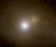

In [57]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

MEGARA/NGC985/megCube-NGC985A_MR-G.fits.gz
MEGARA/NGC985/megCube-NGC985A_MR-G_gri.fits


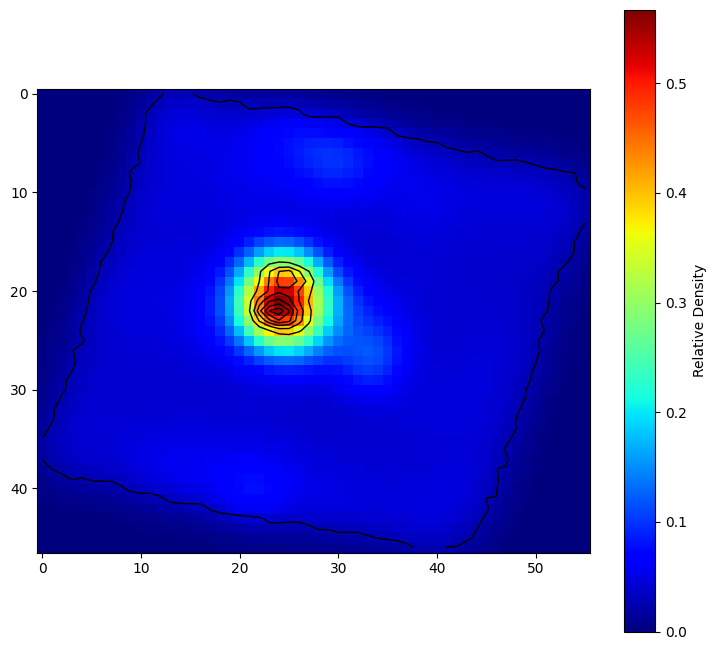

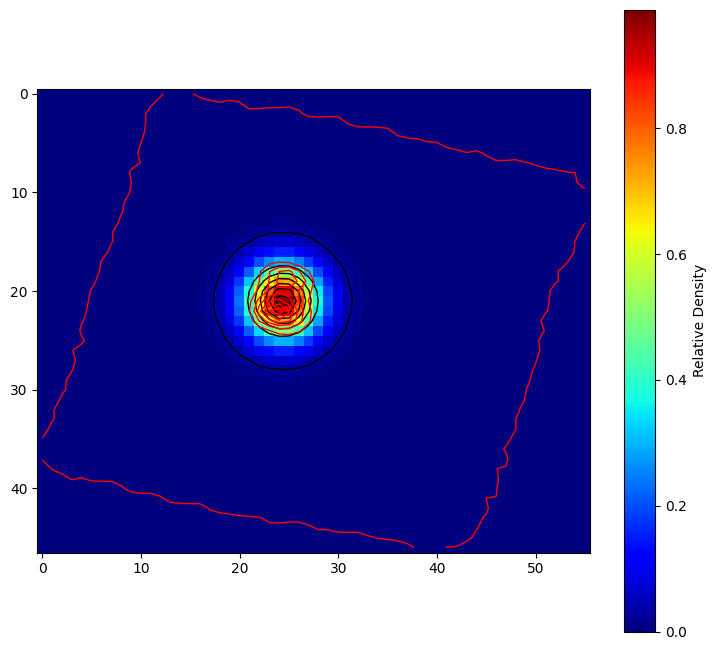

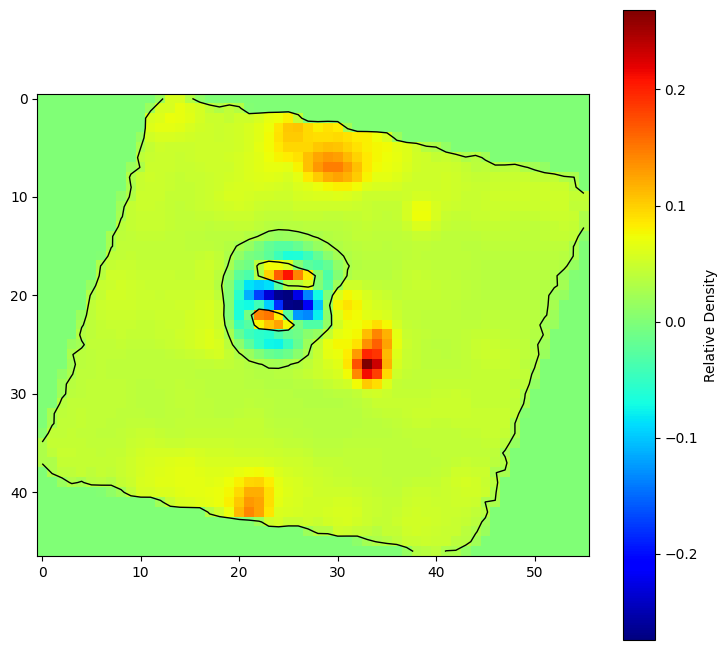

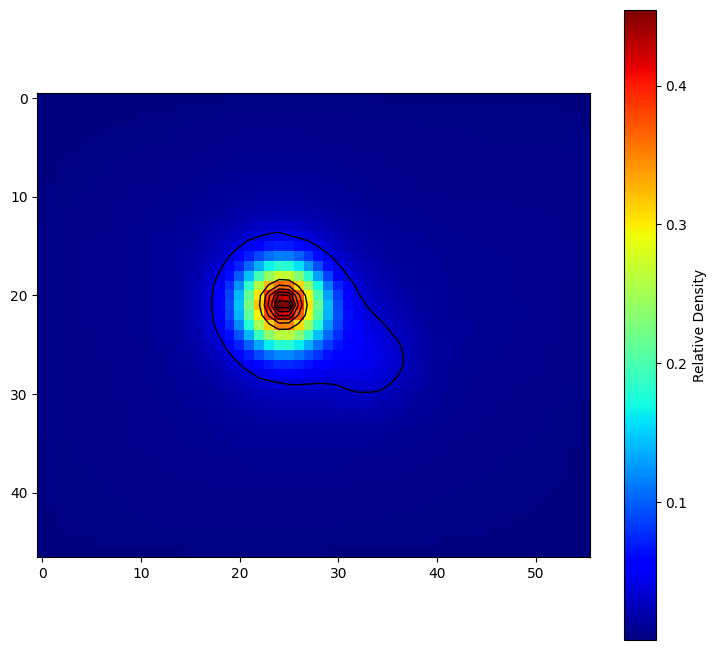

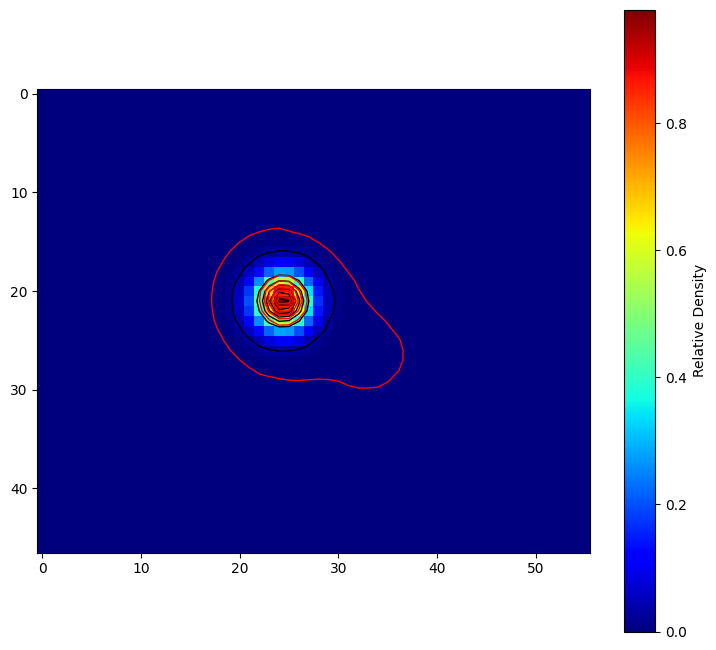

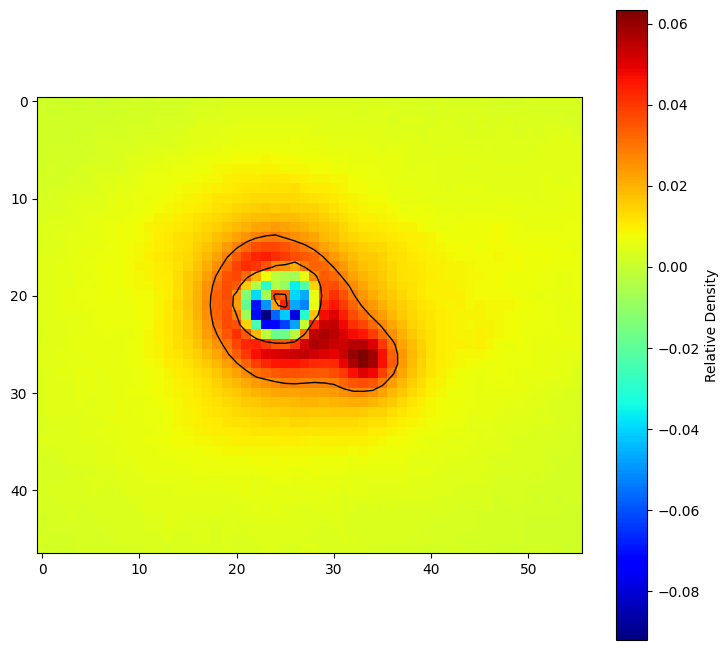

x_0= 24.4 y_0= 21.0 sigma_0= 2.59 psf_0= 4.019292787457567
x_1= 24.4 y_1= 21.0 sigma_1= 1.9 psf_1= 2.948515944466941
02h34m37.84144141s -08d47m16.01640086s RA0,DEC0
02h34m37.84144141s -08d47m16.01640086s RA1,DEC1
x_1_sk= 24.39999999988589 y_1_sk= 20.999999999923574
Dx= 0.0 1.1410961064939329e-10
Dy= 0.0 7.642597665835638e-11


In [58]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Validation of the corrected cube

After applying the pixel correction, the measured centroids coincide.

The residual WCS offsets are of order `10^-11` pixels, which is effectively
zero at the numerical precision of the calculation.

This confirms that the corrected reconstruction is astrometrically aligned
with the reference imaging.

### Aplying to integrated 2D maps 

Processing NGC985
Using WCS and IPA to correct the fiber positions


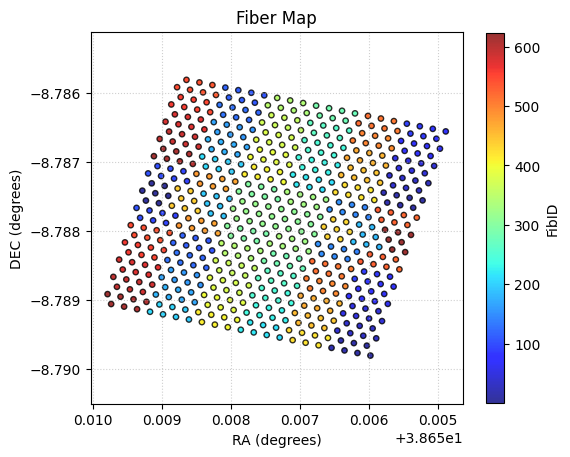

In [59]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'A_'+vph,errors=False,flu16=True,spec_range=(None,None),verbose=True,scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[0.6],dypix=[2.0])

In [60]:
file='megMap-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


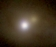

In [61]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [62]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=0)

MEGARA/NGC985/megMap-NGC985A_MR-G.fits.gz
MEGARA/NGC985/megMap-NGC985A_MR-G_gri.fits
x_0= 24.2 y_0= 21.2 sigma_0= 2.38 psf_0= 3.6934041830691156
x_1= 24.2 y_1= 21.2 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.84108919s -08d47m16.03163187s RA0,DEC0
02h34m37.84108919s -08d47m16.03163187s RA1,DEC1
x_1_sk= 24.200000000037946 y_1_sk= 21.2000000000321
Dx= 0.0 -3.794653480326815e-11
Dy= 0.0 -3.2102320801641326e-11


## 7. Align a second MEGARA observation

The same procedure is repeated for a second MEGARA RSS observation.

In [63]:
reduxdir=dir1
reduxL=['RSSOB5'+vph]

In [64]:
mgcube.megmap_ifu(reduxL,nameF=name+'B',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits')

Processing NGC985


In [65]:
file='megCube-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

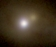

In [66]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

MEGARA/NGC985/megCube-NGC985B_MR-G.fits.gz
MEGARA/NGC985/megCube-NGC985B_MR-G_gri.fits


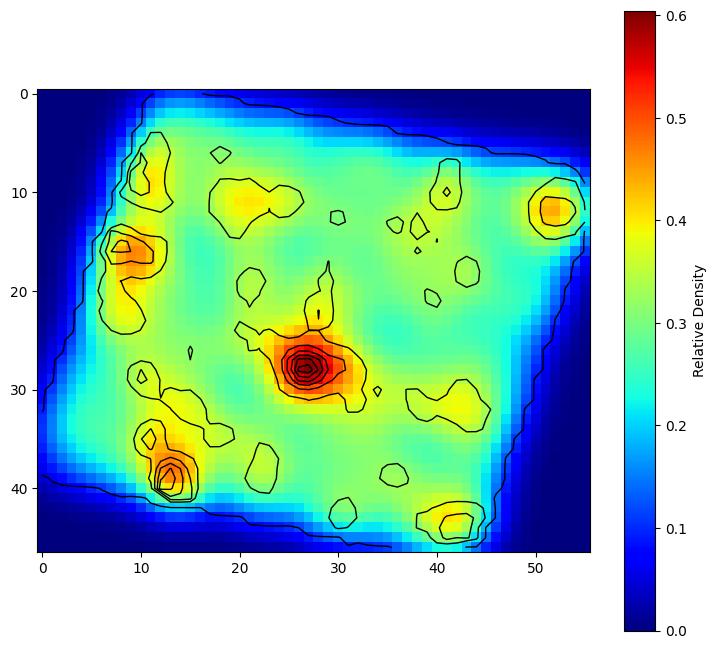

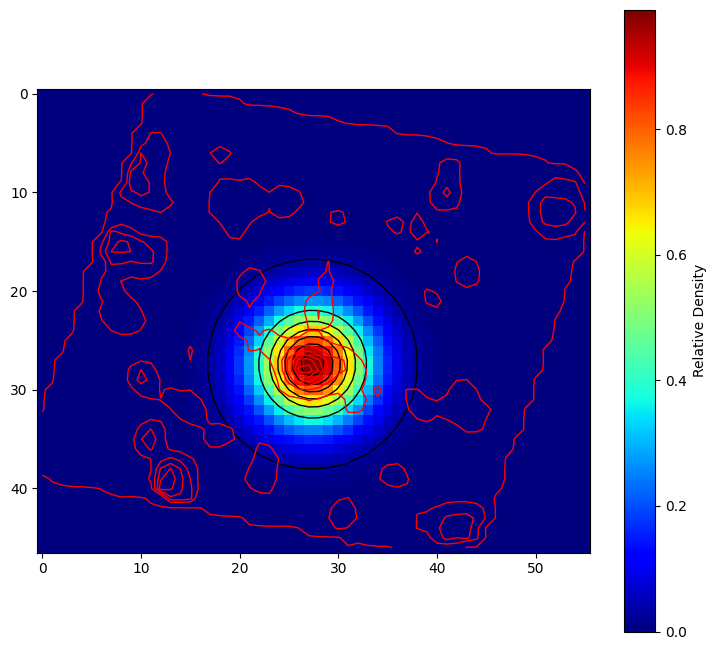

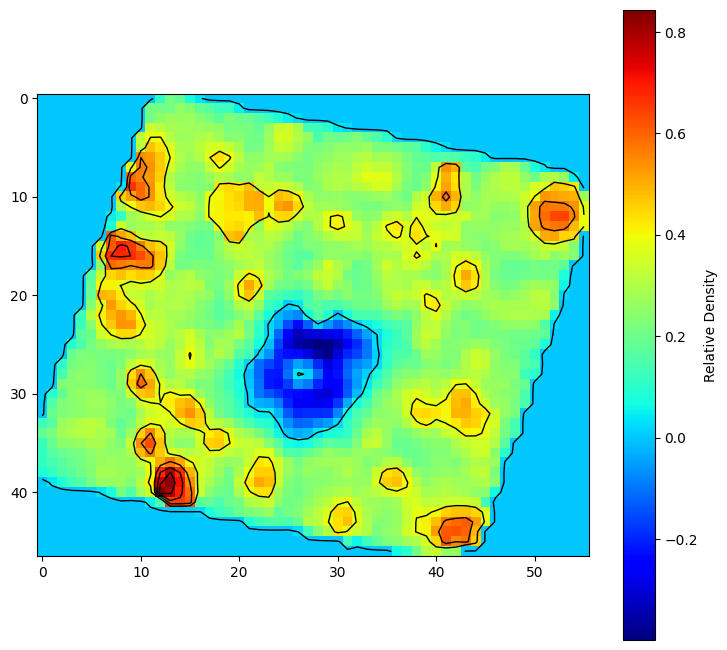

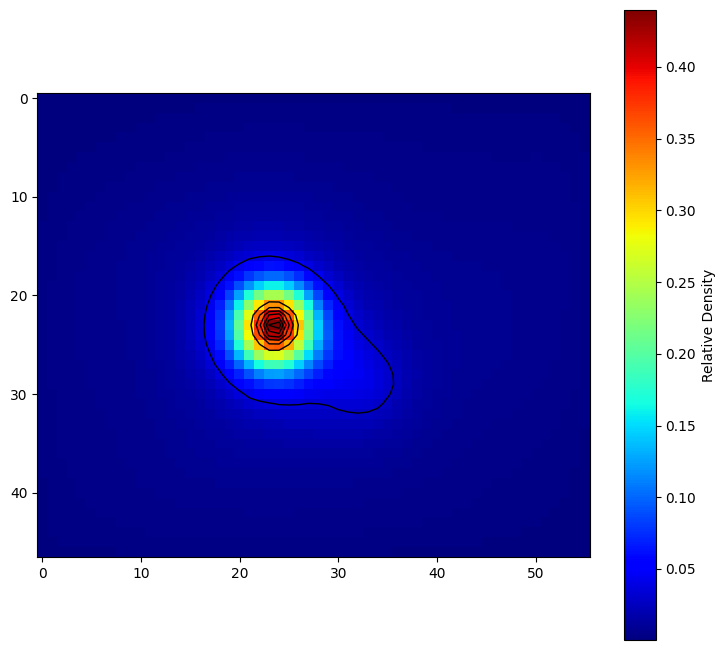

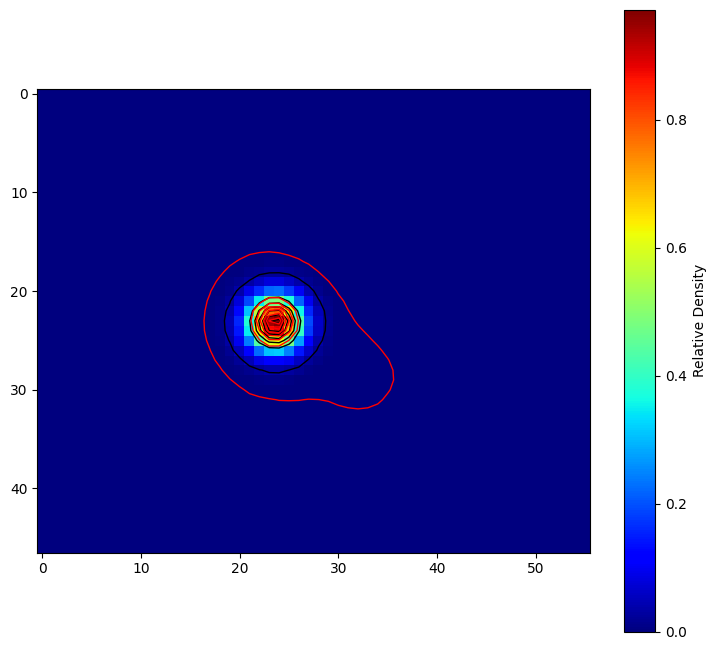

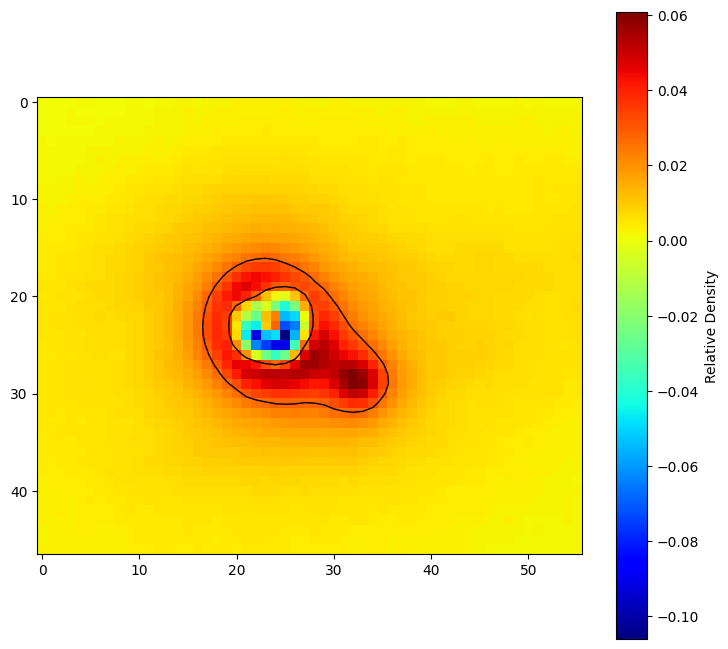

x_0= 27.4 y_0= 27.4 sigma_0= 3.9699999999999998 psf_0= 6.160846473438818
x_1= 23.6 y_1= 23.2 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.75037582s -08d47m14.54297524s RA0,DEC0
02h34m37.8400957s -08d47m16.01297472s RA1,DEC1
x_1_sk= 27.4000000000317 y_1_sk= 27.400000000179848
Dx= 3.799999999999997 -3.800000000031698
Dy= 4.199999999999999 -4.200000000179848


In [67]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Second image shifts
The uncorrected reconstruction shows a substantially larger displacement,
with an offset of approximately:

- 3.8 pixels in X,
- 4.2 pixel in Y.

These offsets are then incorporated into the reconstruction parameters.

In [68]:
mgcube.megmap_ifu(reduxL,nameF=name+'B',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[3.8],dypix=[-4.2])

Processing NGC985


In [69]:
file='megCube-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

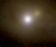

In [70]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [71]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985B_MR-G.fits.gz
MEGARA/NGC985/megCube-NGC985B_MR-G_gri.fits
x_0= 27.4 y_0= 27.4 sigma_0= 3.9699999999999998 psf_0= 6.160846473438818
x_1= 27.4 y_1= 27.4 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.83904247s -08d47m16.01297524s RA0,DEC0
02h34m37.83904247s -08d47m16.01297524s RA1,DEC1
x_1_sk= 27.400000000006358 y_1_sk= 27.400000000182153
Dx= 0.0 -6.359357485052897e-12
Dy= 0.0 -1.8215473573945928e-10


### Validation of the second pointing

After applying the corresponding `dxpix` and `dypix` correction, the two
centroids agree to numerical precision.

This demonstrates that the same procedure can be independently applied to
multiple MEGARA observations before combining them.

### Aplying to integrated 2D maps 

Processing NGC985
Using WCS and IPA to correct the fiber positions


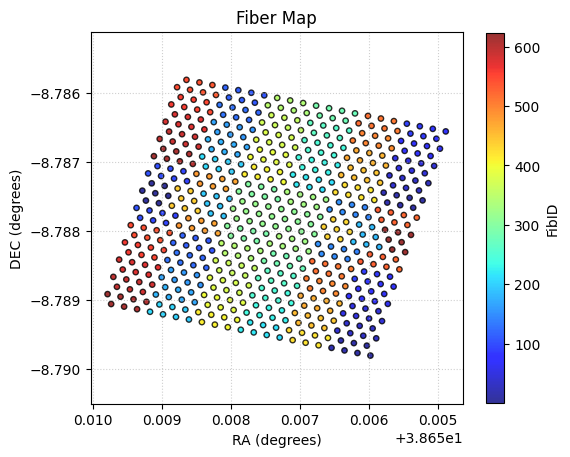

In [72]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'B_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,verbose=True,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[3.6],dypix=[-4.4])

In [73]:
file='megMap-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


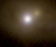

In [74]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [75]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC985B_MR-G.fits.gz
MEGARA/NGC985/megMap-NGC985B_MR-G_gri.fits
x_0= 27.2 y_0= 27.6 sigma_0= 2.11 psf_0= 3.2744045488553923
x_1= 27.2 y_1= 27.6 sigma_1= 1.9 psf_1= 2.948515944466941
02h34m37.84028431s -08d47m16.03167602s RA0,DEC0
02h34m37.84028431s -08d47m16.03167602s RA1,DEC1
x_1_sk= 27.200000000017265 y_1_sk= 27.599999999894422
Dx= 0.0 -1.7266188478970435e-11
Dy= 0.0 1.0557954510659329e-10


## 8. Relative registration between multiple observations

Once each observation has been individually aligned with the external
reference image, their relative registration must also be checked before
coaddition.

To isolate the contribution of each RSS observation, reconstructed maps
are generated separately using the `facT` parameter.

The resulting products are then compared with `astromatch`. To a quick analysis we use the MAP (`meggen_map`) function instead of the full CUBE data (`megmap_ifu`) 

In [76]:
reduxdir=dir1
reduxL=['RSSOB1'+vph,'RSSOB5'+vph]
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'1_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[0.8,3.8],dypix=[2.2,-4.2],facT=[1,0])
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'2_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[0.8,3.8],dypix=[2.2,-4.2],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [77]:
file='megMap-NAME1_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megMap-NAME2_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC9851_MR-G.fits.gz
MEGARA/NGC985/megMap-NGC9852_MR-G.fits.gz
x_0= 24.2 y_0= 27.4 sigma_0= 2.38 psf_0= 3.6934041830691156
x_1= 30.2 y_1= 27.4 sigma_1= 2.14 psf_1= 3.3209600637680285
02h34m37.91618491s -08d47m15.96165328s RA0,DEC0
02h34m37.77452193s -08d47m15.961654s RA1,DEC1
x_1_sk= 24.200000000069117 y_1_sk= 27.40000000009312
Dx= -6.0 5.999999999930882
Dy= 0.0 -9.312017823503993e-11


### Relative offset between observations

The first comparison reveals an additional relative displacement between
the two reconstructed observations.

This residual offset is incorporated into the individual `dxpix` and
`dypix` corrections before the final combination.

## 9. Refine the relative registration

The relative offsets measured between the two observations are added to
the previous individual corrections.

New maps are generated and compared again.

After this refinement, the measured centroids agree to numerical
precision, indicating that the two MEGARA observations are now mutually
registered.

In [78]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'1_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[1,0])
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'2_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [79]:
file='megMap-NAME1_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megMap-NAME2_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC9851_MR-G.fits.gz
MEGARA/NGC985/megMap-NGC9852_MR-G.fits.gz
x_0= 27.2 y_0= 27.4 sigma_0= 2.38 psf_0= 3.6934041830691156
x_1= 27.2 y_1= 27.4 sigma_1= 2.05 psf_1= 3.1812935190301204
02h34m37.91535342s -08d47m15.96165405s RA0,DEC0
02h34m37.91535342s -08d47m15.96165405s RA1,DEC1
x_1_sk= 27.200000000001747 y_1_sk= 27.4000000000096
Dx= 0.0 -1.7479351299698465e-12
Dy= 0.0 -9.602985073797754e-12


## 10. Validate the registration in the reconstructed cubes

The alignment determined from the reconstructed maps is propagated to the
full spectral cubes.

Because the PSF centroid measured from the full cube can differ slightly
from that measured in the collapsed maps, an additional fine adjustment
may be required.

The two reconstructed cubes are therefore compared directly with
`astromatch`.

In [80]:
mgcube.megmap_ifu(reduxL,nameF=name+'1',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[1,0])
mgcube.megmap_ifu(reduxL,nameF=name+'2',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [81]:
file='megCube-NAME1_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megCube-NAME2_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC9852_LR-R.fits.gz
x_0= 26.8 y_0= 20.4 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 26.8 y_1= 20.4 sigma_1= 1.78 psf_1= 2.7622938848163976
02h34m37.96746827s -08d47m16.01366273s RA0,DEC0
02h34m37.96746827s -08d47m16.01366273s RA1,DEC1
x_1_sk= 26.800000000182024 y_1_sk= 20.400000000069117
Dx= 0.0 -1.8202328533334367e-10
Dy= 0.0 -6.911804462106375e-11


### Fine correction

A small additional correction is applied to the first observation to
remove the remaining relative displacement.

After rebuilding the cubes, the X centroid difference is reduced to approximately 1.8 pixels,
while the remaining Y residual is reduced to zero and is
negligible compared with the adopted spatial sampling.

In [82]:
mgcube.megmap_ifu(reduxL,nameF=name+'1',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[1,0])
mgcube.megmap_ifu(reduxL,nameF=name+'2',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [83]:
file='megCube-NAME1_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megCube-NAME2_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC9852_LR-R.fits.gz
x_0= 26.8 y_0= 20.4 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 26.8 y_1= 20.4 sigma_1= 1.78 psf_1= 2.7622938848163976
02h34m37.96746827s -08d47m16.01366273s RA0,DEC0
02h34m37.96746827s -08d47m16.01366273s RA1,DEC1
x_1_sk= 26.800000000182024 y_1_sk= 20.400000000069117
Dx= 0.0 -1.8202328533334367e-10
Dy= 0.0 -6.911804462106375e-11


## 11. Final combined cube

Once the individual observations are aligned, they are combined using

```python
facT=[1,1]
```

to include both RSS datasets in the final reconstructed cube.

The combined cube is then compared once more with the external imaging.
This final check ensures that the astrometric registration has been
preserved during the coaddition.

Processing NGC985
Using WCS and IPA to correct the fiber positions
Processing NGC985
Using WCS and IPA to correct the fiber positions


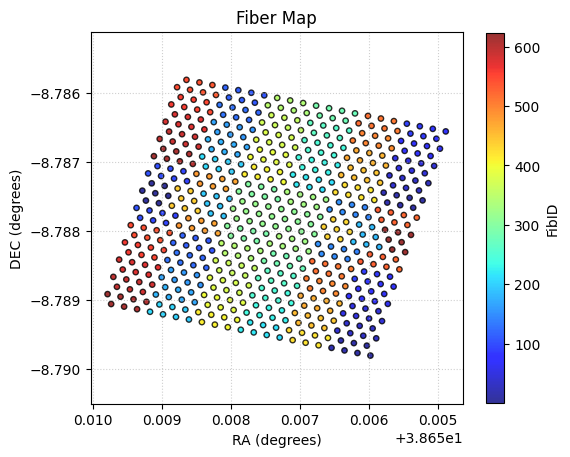

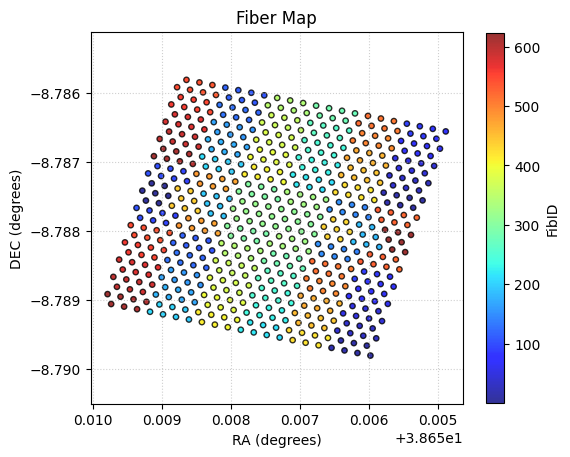

In [84]:
mgcube.megmap_ifu(reduxL,nameF=name,errors=False,flu16=True,spec_range=(None,None),headerInfo={},verbose=True,scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[1,0])

In [85]:
file='megCube-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

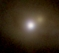

In [86]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [87]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985_MR-G.fits.gz
MEGARA/NGC985/megCube-NGC985_MR-G_gri.fits
x_0= 27.4 y_0= 27.2 sigma_0= 2.62 psf_0= 4.0658483023702034
x_1= 30.4 y_1= 27.2 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.91024021s -08d47m16.01466083s RA0,DEC0
02h34m37.83940872s -08d47m16.01466072s RA1,DEC1
x_1_sk= 27.400000000027493 y_1_sk= 27.199999999974615
Dx= -3.0 2.9999999999725055
Dy= 0.0 2.538413923502958e-11


### Global astrometric correction

Although the individual observations are internally aligned, the combined
cube may still exhibit a global displacement with respect to the external
reference frame.

For the combined reconstruction, a residual offset of approximately

- -3.0 pixels in X,
- 0.0 pixels in Y

is detected.

This global shift is corrected using the `dx` and `dy` parameters of the
reconstruction routine.

## 12. Final astrometric solution

The global correction is applied directly during the cube reconstruction:

```python
dx=-3.0
dy=0.05
```
After rebuilding the cube and reprojecting the reference imaging, the
measured centroids agree to numerical precision.

The final WCS residuals are approximately 10^-11 pixels, demonstrating
that the reconstructed MEGARA cube is astrometrically aligned with the
external imaging reference.

In [88]:
mgcube.megmap_ifu(reduxL,nameF=name,errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dtheta_ipa=dtheta_ipa,
    dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[1,0],dx=-3.0,dy=0.05)

Processing NGC985
Processing NGC985


In [89]:
file='megCube-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

In [90]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985_MR-G.fits.gz
MEGARA/NGC985/megCube-NGC985_MR-G_gri.fits
x_0= 27.4 y_0= 27.2 sigma_0= 2.62 psf_0= 4.0658483023702034
x_1= 27.4 y_1= 27.2 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.83940872s -08d47m16.03216072s RA0,DEC0
02h34m37.83940872s -08d47m16.03216072s RA1,DEC1
x_1_sk= 27.40000000000018 y_1_sk= 27.199999999910794
Dx= 0.0 -1.8118839761882555e-13
Dy= 0.0 8.920508776100178e-11


## 13. Final reconstructed 2D map

The same astrometric solution can be applied when generating a final
two-dimensional reconstructed map.

The resulting map is reprojected against the same external imaging and
validated with `astromatch`.

The final comparison again gives residuals consistent with zero, showing
that the astrometric solution is preserved in both the reconstructed
spectral cube and the derived 2D map.

In [91]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dtheta_ipa=dtheta_ipa,
    dxpix=[0.8+6,3.8],dypix=[2.2,-4.2],facT=[1,0],dx=-3.2,dy=0.2)

Processing NGC985
Processing NGC985


In [92]:
file='megMap-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


In [93]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC985_MR-G.fits.gz
MEGARA/NGC985/megMap-NGC985_MR-G_gri.fits
x_0= 27.2 y_0= 27.4 sigma_0= 2.38 psf_0= 3.6934041830691156
x_1= 27.2 y_1= 27.4 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.83979983s -08d47m16.03165396s RA0,DEC0
02h34m37.83979983s -08d47m16.03165396s RA1,DEC1
x_1_sk= 27.19999999980218 y_1_sk= 27.3999999997628
Dx= 0.0 1.978186503492907e-10
Dy= 0.0 2.3719692876511544e-10


## Summary

This notebook demonstrates an iterative astrometric alignment workflow for
MEGARA data reconstructed with 3DCubeGen.

The procedure can be summarized as:

1. Reconstruct each MEGARA observation.
2. Reproject external imaging onto the IFU spatial grid with `crop_image`.
3. Measure centroid offsets with `astromatch`.
4. Correct individual RSS positions using `dxpix` and `dypix`.
5. Verify the relative registration between multiple observations.
6. Apply any remaining global shift using `dx` and `dy`.
7. Reconstruct the final combined cube and map.
8. Validate the final astrometric solution against the external reference.

For NGC 985, the final reconstructed products reach astrometric residuals
consistent with zero at numerical precision.

> **Note**
>
> `dxpix` and `dypix` correct the relative position of individual RSS
> observations before their combination, whereas `dx` and `dy` apply a
> global shift to the final reconstructed coordinate grid.
>
> In practice, the alignment should therefore be performed in two stages:
> first the relative registration between exposures, and then the absolute
> registration against an external astrometric reference.

# Part III — LR-B reconstruction and astrometric alignment

The LR-B configuration follows the same iterative alignment strategy. Unlike MR-G, the source notebook uses no additional rotation or X-axis stretch (`dtheta_ipa = 0`, `scfx = 1`). The observation-specific and global translational corrections are then determined from the astrometric comparisons.

## 3. Initial cube reconstruction

We first reconstruct the MEGARA observation without applying any
astrometric correction.

The reconstructed cube is generated with a spatial sampling of
0.35 arcsec per pixel and a Gaussian reconstruction kernel.

At this stage, the resulting cube retains the astrometric solution
derived from the original observation.

`dtheta_ipa` is the PA ofset to use, generally it is zero.

In [94]:
dtheta_ipa=0.0#90+15.09
scfx=1.0#1.3

In [95]:
vph='LR-B'

In [96]:
reduxdir=dir1
reduxL=['RSSOB1'+vph]

Processing NGC985
Using WCS and IPA to correct the fiber positions


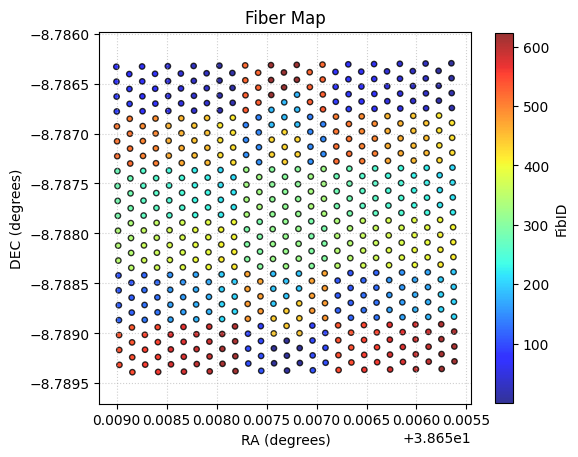

In [97]:
mgcube.megmap_ifu(reduxL,nameF=name+'A',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',verbose=True)

## 4. Reproject external imaging onto the IFU grid

External broad-band images are reprojected onto the spatial coordinate
system of the reconstructed MEGARA cube using `crop_image`.

For this example, SDSS-like `i`, `r`, and `g` images are used:

- `i` -> red channel
- `r` -> green channel
- `g` -> blue channel

The output FITS image has the same spatial WCS and pixel grid as the
reconstructed MEGARA cube. An RGB JPEG representation is also produced.

In [98]:
file='megCube-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

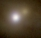

In [99]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

## 5. Measure the astrometric offset

The astrometric registration is evaluated with `astromatch`.

The function:

1. collapses each cube/image along its first axis,
2. fits a 2D PSF to determine the centroid,
3. converts the centroid of the reference cube to sky coordinates,
4. projects that sky position onto the second image,
5. computes the difference between the measured and expected positions.

The relevant residuals are the WCS-based offsets in the second pair of
reported values.

A residual close to zero indicates that the source centroid is consistent
with the WCS registration.

MEGARA/NGC985/megCube-NGC985A_LR-B.fits.gz
MEGARA/NGC985/megCube-NGC985A_LR-B_gri.fits


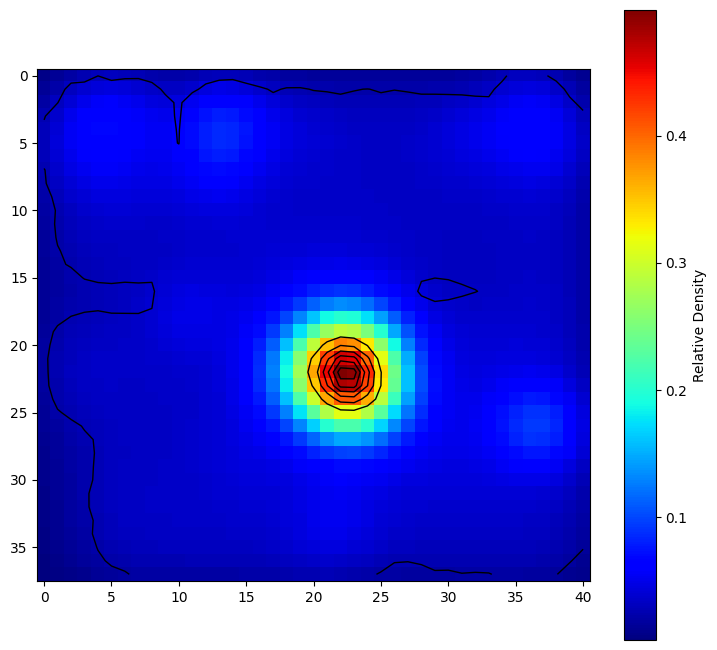

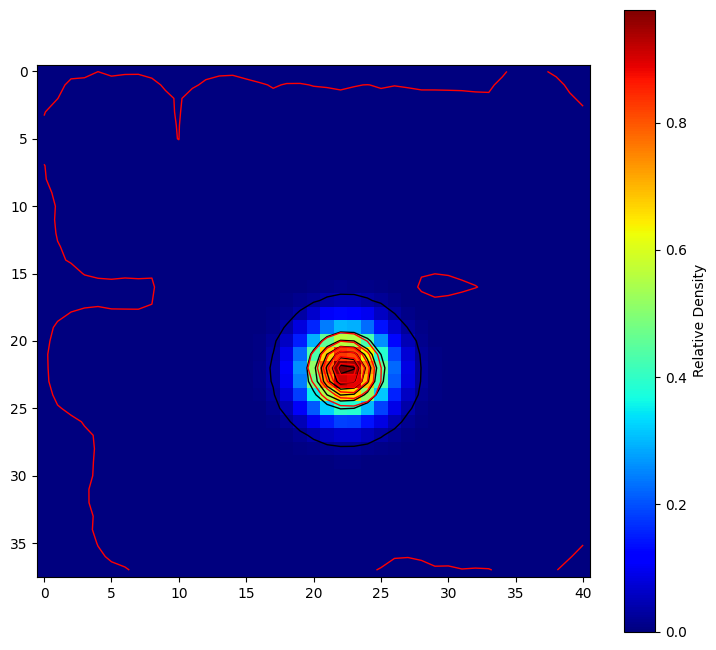

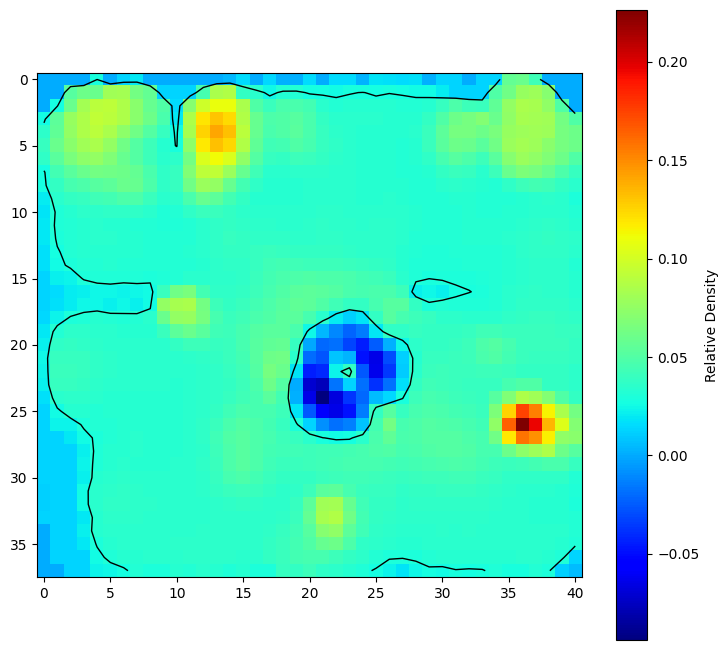

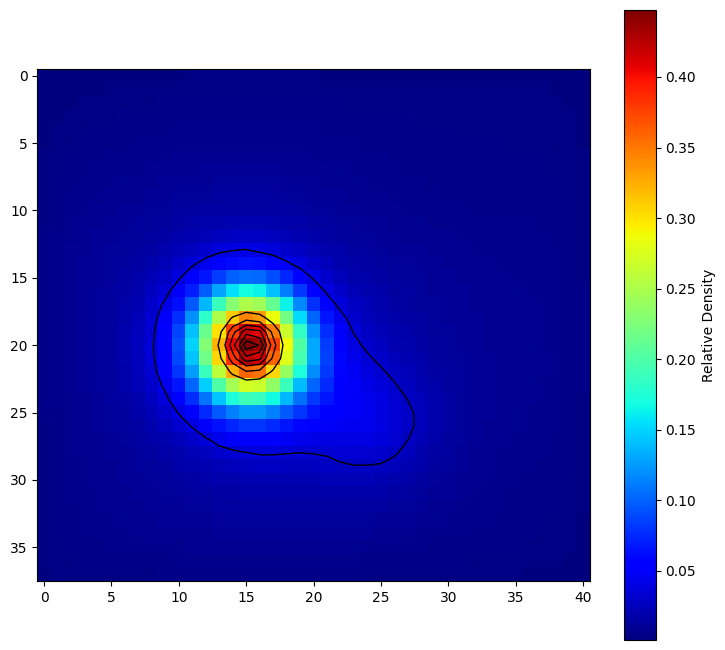

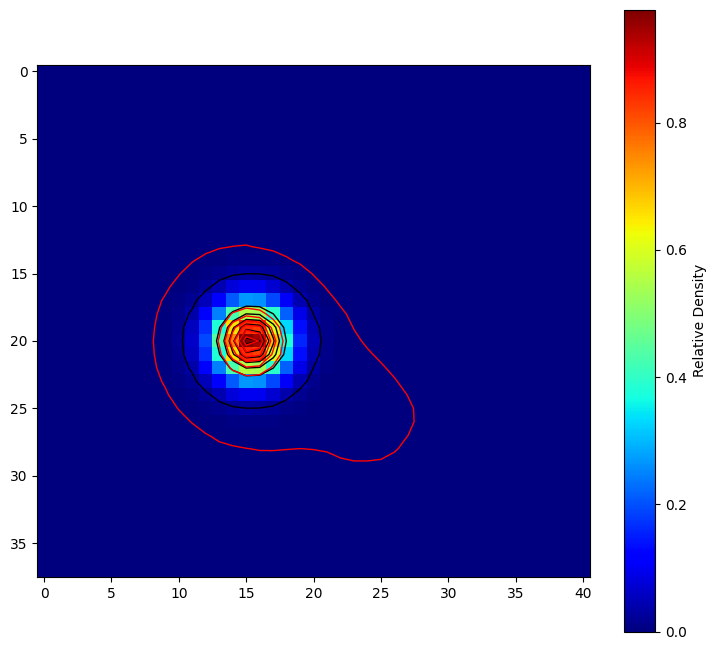

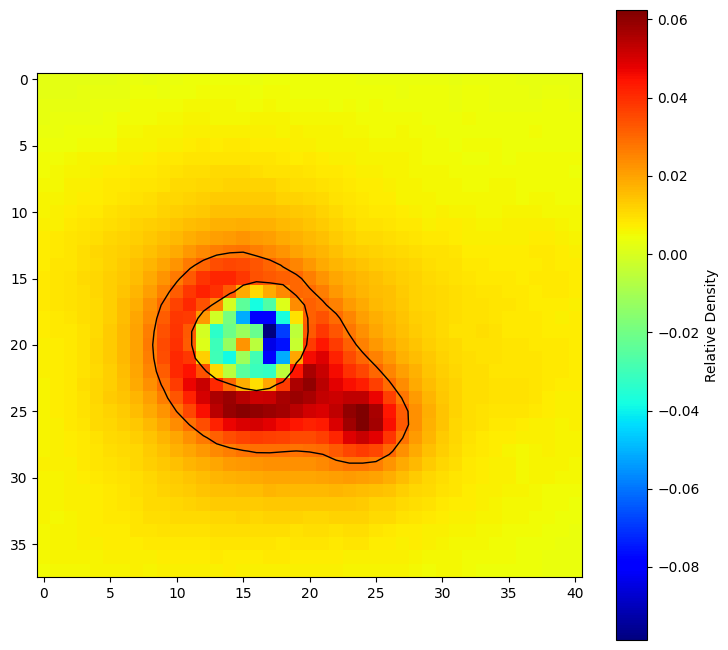

x_0= 22.4 y_0= 22.2 sigma_0= 2.08 psf_0= 3.2278490339427566
x_1= 15.4 y_1= 20.0 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.67372096s -08d47m15.29977505s RA0,DEC0
02h34m37.83899441s -08d47m16.06977467s RA1,DEC1
x_1_sk= 22.399999999947994 y_1_sk= 22.199999999958962
Dx= 6.999999999999998 -6.999999999947994
Dy= 2.1999999999999993 -2.199999999958962


In [100]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Initial offset

For the first reconstruction, the measured centroid displacement is

- approximately 7 pixels in X,
- approximately 2.2 pixels in Y.

This indicates that an astrometric correction is required before combining
or comparing the reconstructed MEGARA data with the external imaging.

## 6. Apply the first astrometric correction

The measured displacement is supplied to the reconstruction through
`dxpix` and `dypix`.

These parameters shift the individual RSS contribution before generating
the reconstructed cube or map.

After applying the correction, the reconstructed product is generated
again and compared with the reference imaging.

In [101]:
mgcube.megmap_ifu(reduxL,nameF=name+'A',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[7.1],dypix=[-2.2])

Processing NGC985


In [102]:
file='megCube-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

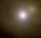

In [103]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

MEGARA/NGC985/megCube-NGC985A_LR-B.fits.gz
MEGARA/NGC985/megCube-NGC985A_LR-B_gri.fits


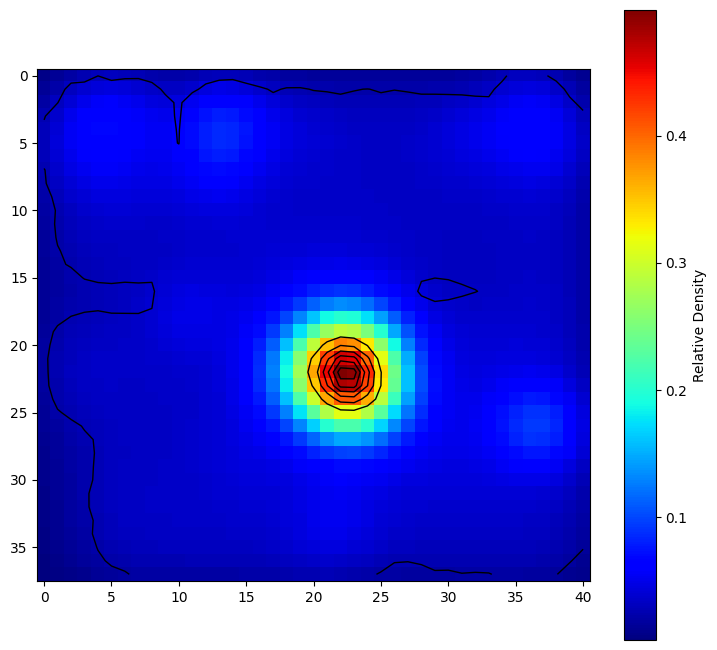

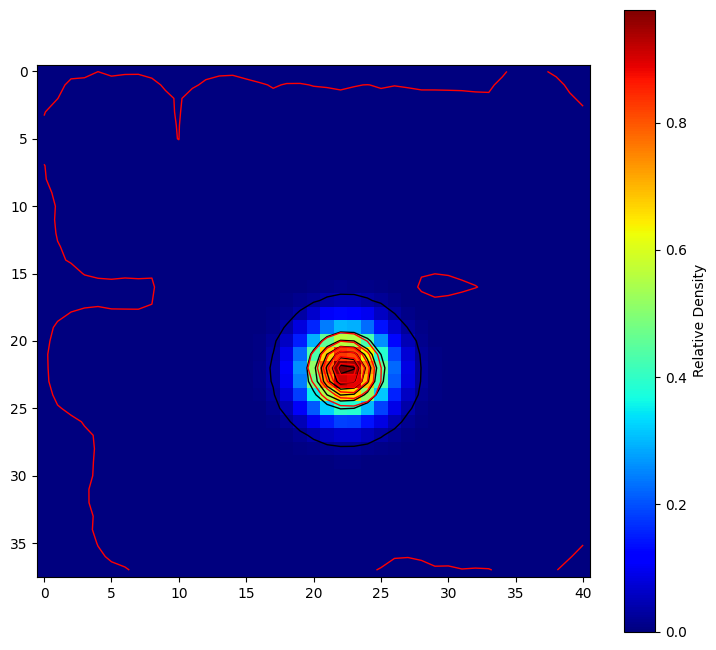

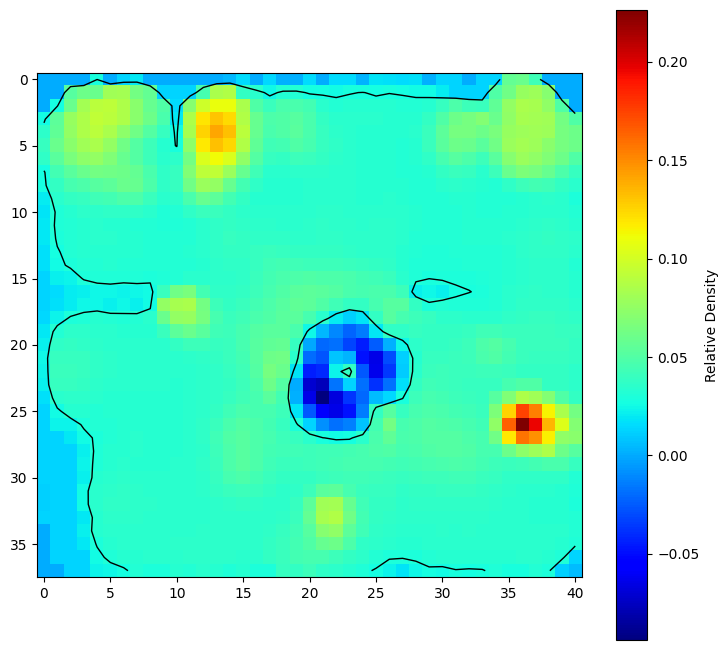

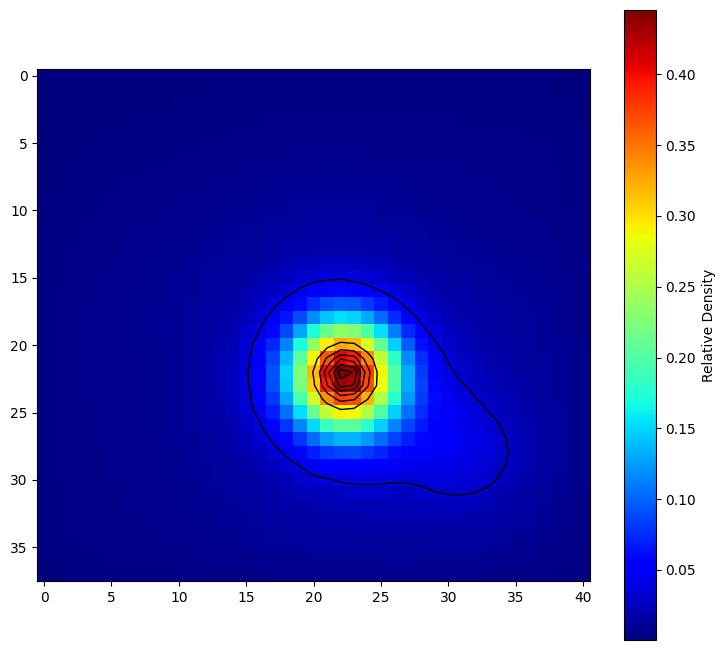

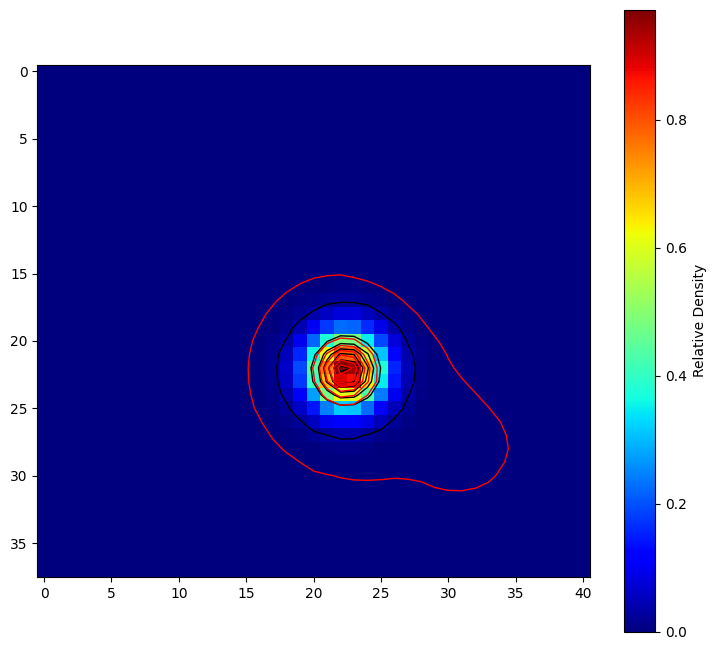

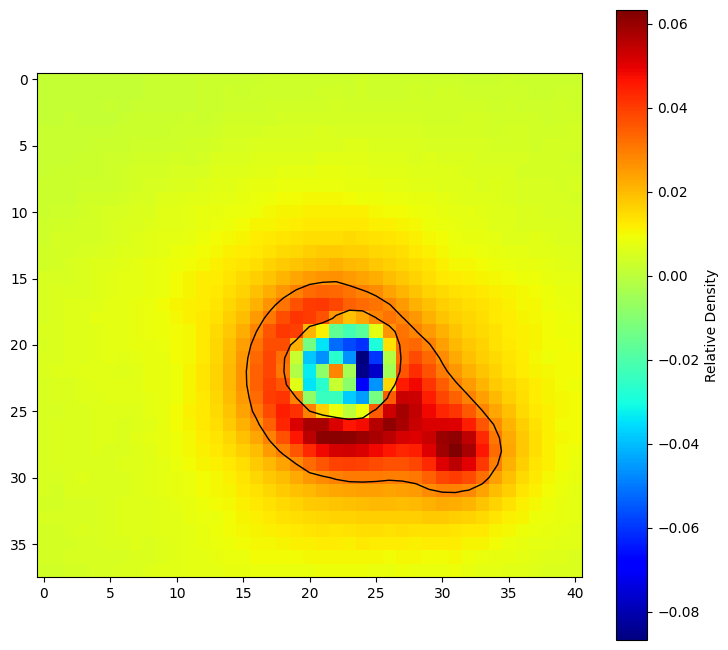

x_0= 22.4 y_0= 22.2 sigma_0= 2.08 psf_0= 3.2278490339427566
x_1= 22.4 y_1= 22.2 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.83938759s -08d47m16.06977505s RA0,DEC0
02h34m37.83938759s -08d47m16.06977505s RA1,DEC1
x_1_sk= 22.399999999946505 y_1_sk= 22.199999999793867
Dx= 0.0 5.349320986169914e-11
Dy= 0.0 2.0613200035768386e-10


In [104]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Validation of the corrected cube

After applying the pixel correction, the measured centroids coincide.

The residual WCS offsets are of order `10^-11` pixels, which is effectively
zero at the numerical precision of the calculation.

This confirms that the corrected reconstruction is astrometrically aligned
with the reference imaging.

### Aplying to integrated 2D maps 

Processing NGC985
Using WCS and IPA to correct the fiber positions


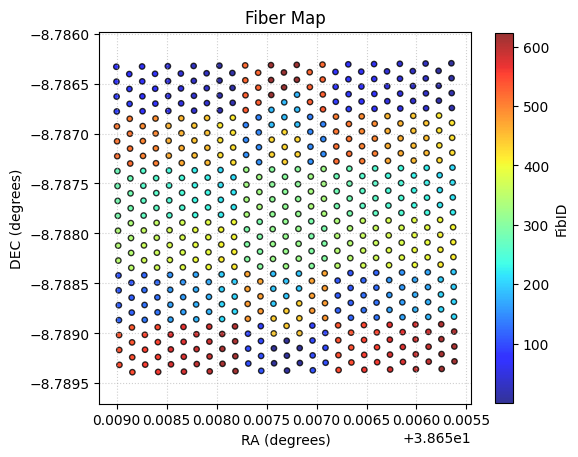

In [105]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'A_'+vph,errors=False,flu16=True,spec_range=(None,None),verbose=True,scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[6.2],dypix=[-2.4])

In [106]:
file='megMap-NAMEA_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


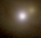

In [107]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [108]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=0)

MEGARA/NGC985/megMap-NGC985A_LR-B.fits.gz
MEGARA/NGC985/megMap-NGC985A_LR-B_gri.fits
x_0= 22.0 y_0= 21.4 sigma_0= 1.99 psf_0= 3.088182489204849
x_1= 22.0 y_1= 21.4 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.84039529s -08d47m16.05843142s RA0,DEC0
02h34m37.84039529s -08d47m16.05843142s RA1,DEC1
x_1_sk= 22.000000000145064 y_1_sk= 21.400000000132323
Dx= 0.0 -1.4506440493278205e-10
Dy= 0.0 -1.3232437368060346e-10


## 7. Align a second MEGARA observation

The same procedure is repeated for a second MEGARA RSS observation.

In [109]:
reduxdir=dir1
reduxL=['RSSOB5'+vph]

In [110]:
mgcube.megmap_ifu(reduxL,nameF=name+'B',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits')

Processing NGC985


In [111]:
file='megCube-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

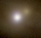

In [112]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

MEGARA/NGC985/megCube-NGC985B_LR-B.fits.gz
MEGARA/NGC985/megCube-NGC985B_LR-B_gri.fits


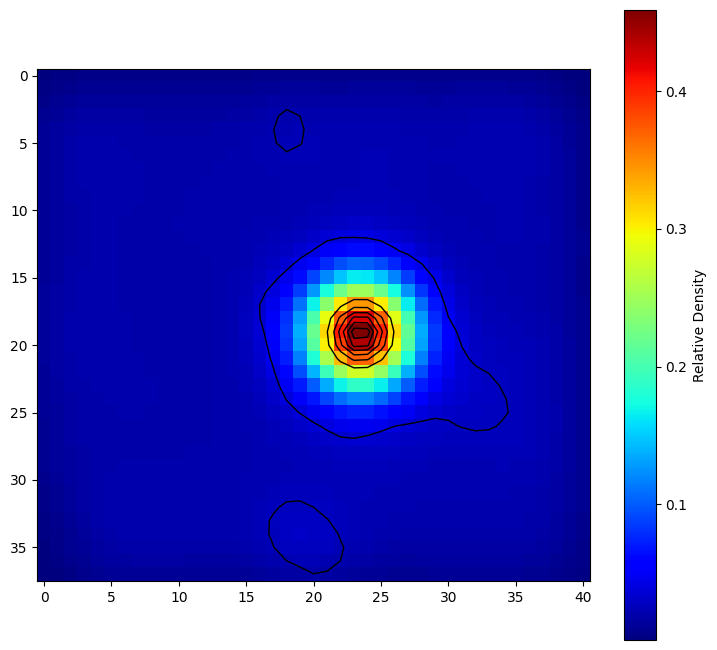

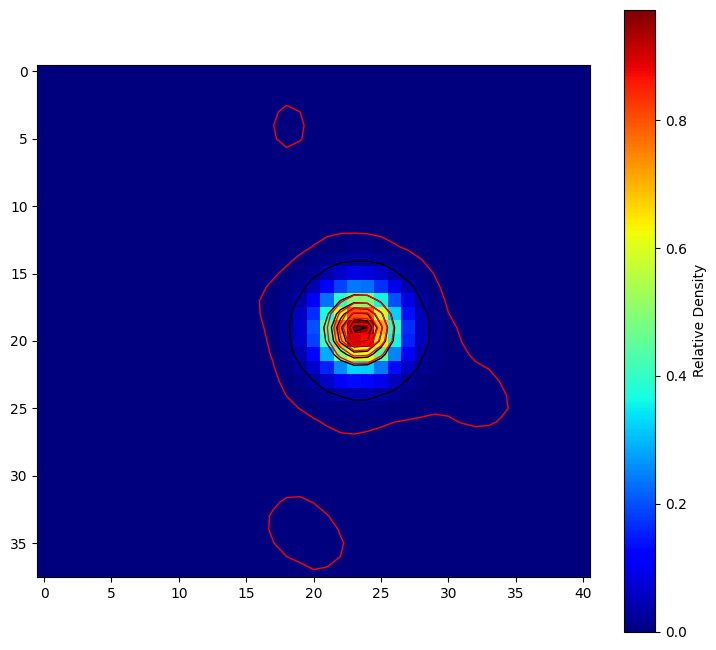

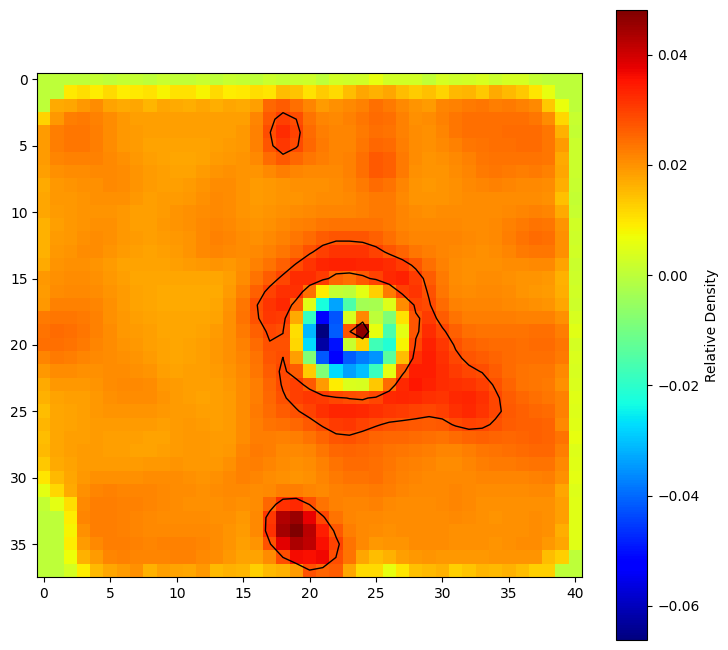

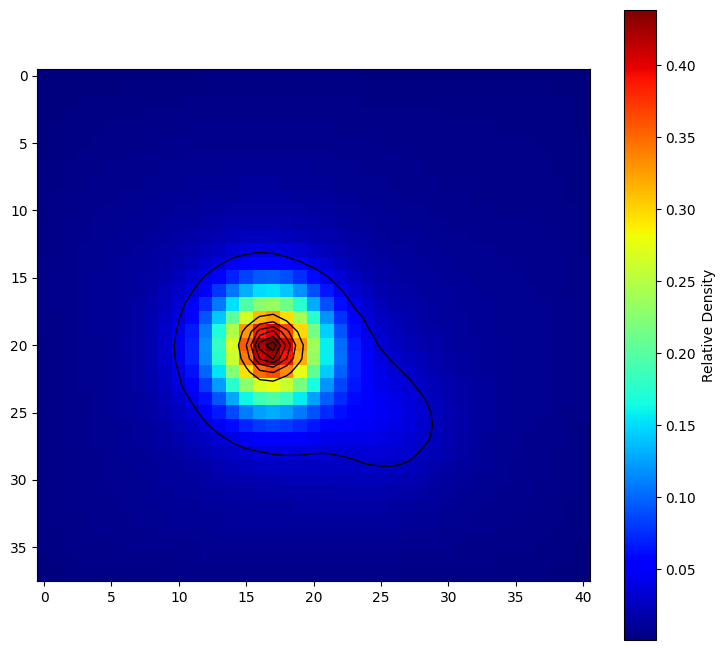

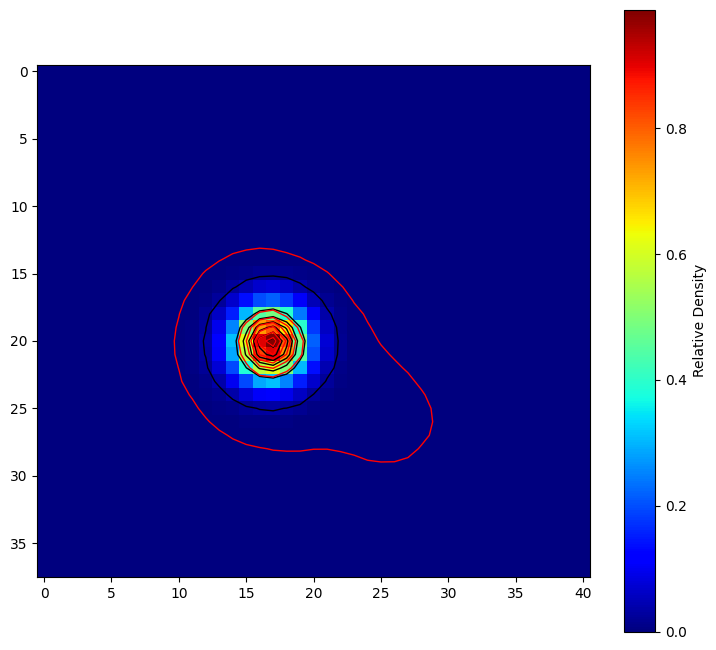

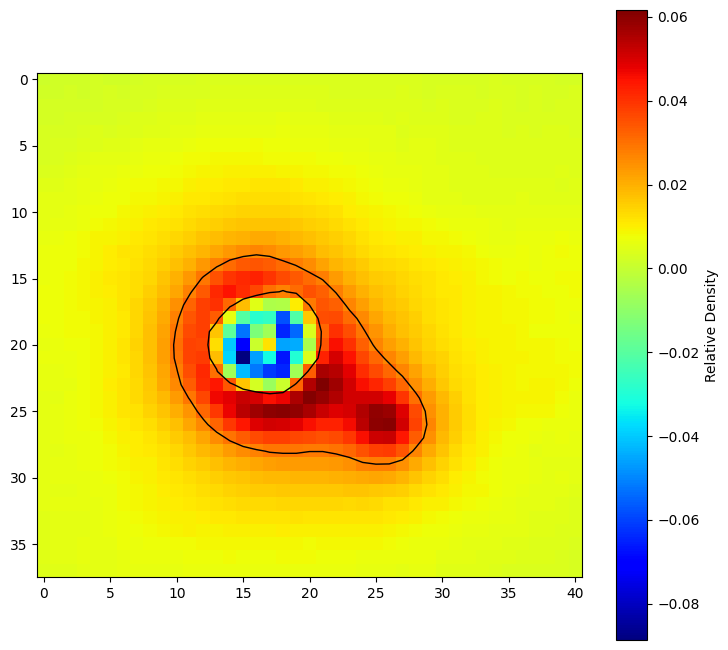

x_0= 23.4 y_0= 19.2 sigma_0= 1.9 psf_0= 2.948515944466941
x_1= 16.8 y_1= 20.2 sigma_1= 1.84 psf_1= 2.8554049146416696
02h34m37.68559364s -08d47m16.39803044s RA0,DEC0
02h34m37.84142295s -08d47m16.04803081s RA1,DEC1
x_1_sk= 23.399999999932383 y_1_sk= 19.200000000047638
Dx= 6.599999999999998 -6.599999999932383
Dy= -1.0 0.9999999999523617


In [113]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

### Second image shifts
The uncorrected reconstruction shows a substantially larger displacement,
with an offset of approximately:

- 6.6 pixels in X,
- -1.0 pixel in Y.

These offsets are then incorporated into the reconstruction parameters.

In [114]:
mgcube.megmap_ifu(reduxL,nameF=name+'B',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[6.6],dypix=[1.0])

Processing NGC985


In [115]:
file='megCube-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

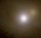

In [116]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [117]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985B_LR-B.fits.gz
MEGARA/NGC985/megCube-NGC985B_LR-B_gri.fits
x_0= 23.4 y_0= 19.2 sigma_0= 1.9 psf_0= 2.948515944466941
x_1= 23.4 y_1= 19.2 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.83959367s -08d47m16.04803044s RA0,DEC0
02h34m37.83959367s -08d47m16.04803044s RA1,DEC1
x_1_sk= 23.399999999929342 y_1_sk= 19.200000000064584
Dx= 0.0 7.065636964398436e-11
Dy= 0.0 -6.45847819669143e-11


### Validation of the second pointing

After applying the corresponding `dxpix` and `dypix` correction, the two
centroids agree to numerical precision.

This demonstrates that the same procedure can be independently applied to
multiple MEGARA observations before combining them.

### Aplying to integrated 2D maps 

Processing NGC985
Using WCS and IPA to correct the fiber positions


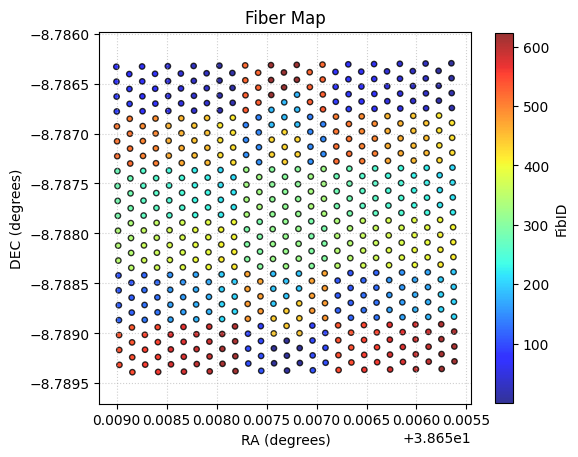

In [118]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'B_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,verbose=True,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[8.4],dypix=[0.6])

In [119]:
file='megMap-NAMEB_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


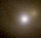

In [120]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

MEGARA/NGC985/megMap-NGC985B_LR-B.fits.gz
MEGARA/NGC985/megMap-NGC985B_LR-B_gri.fits


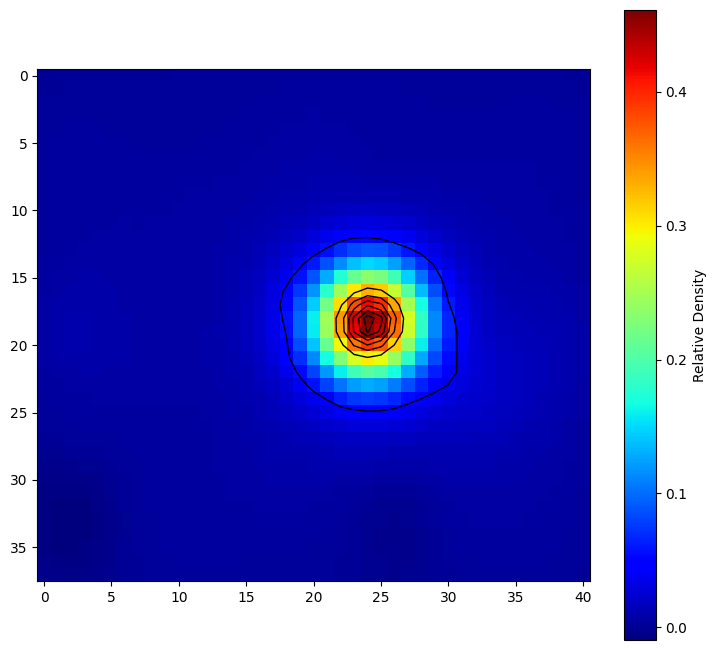

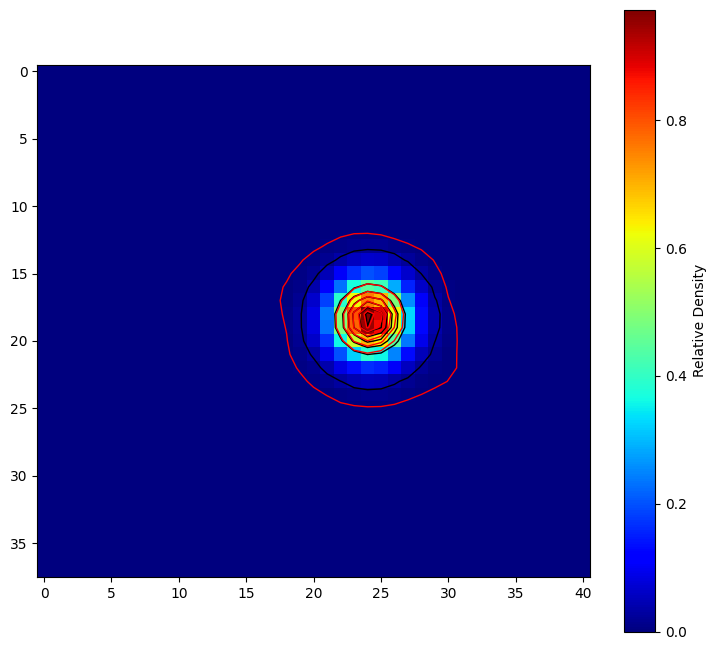

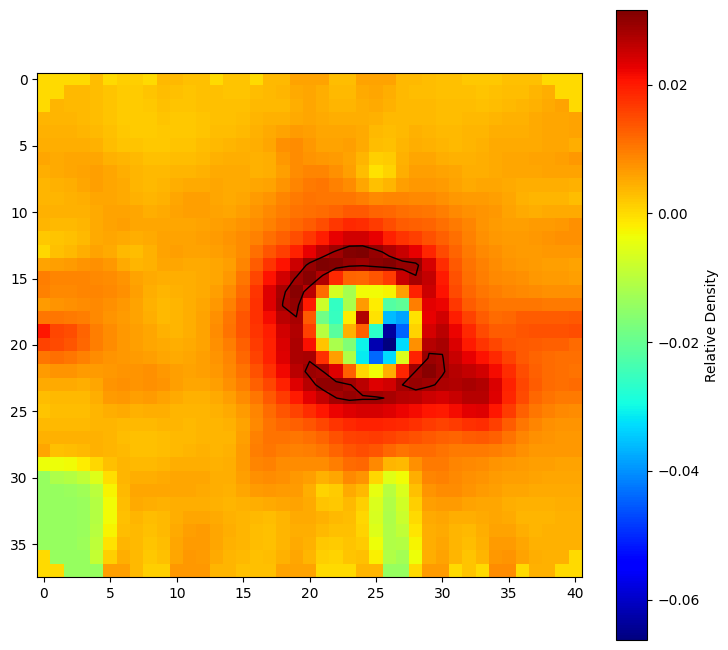

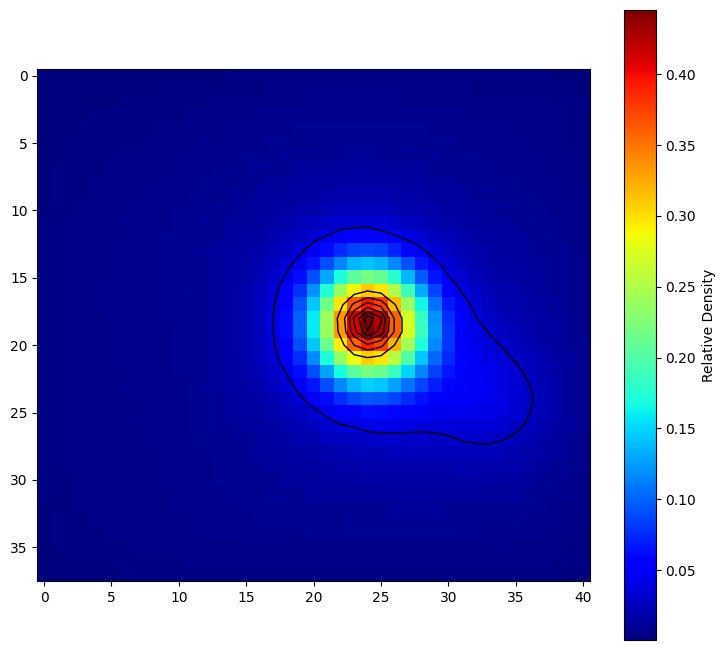

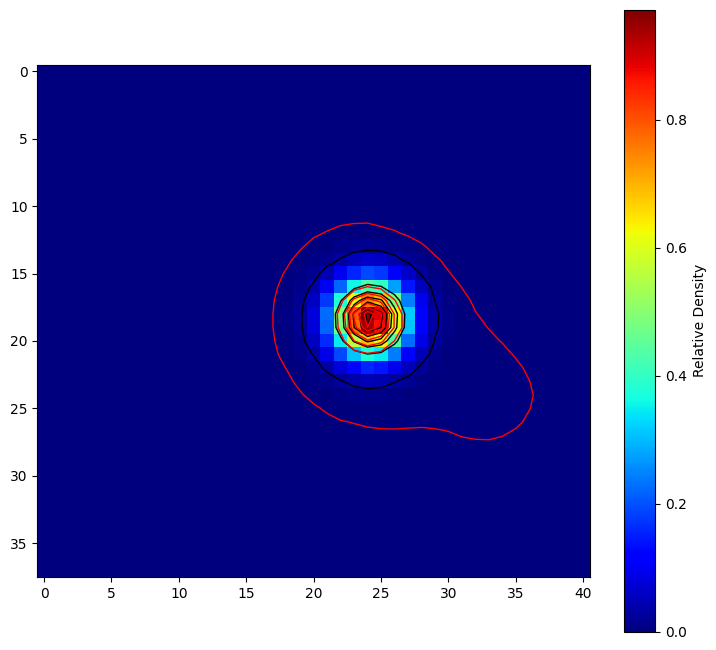

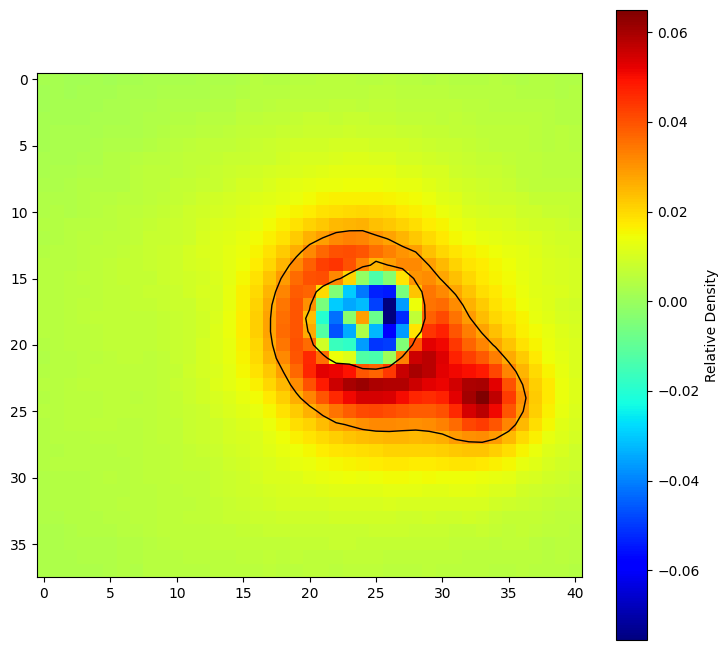

x_0= 24.2 y_0= 18.4 sigma_0= 1.9 psf_0= 2.948515944466941
x_1= 24.2 y_1= 18.4 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.83980709s -08d47m16.05847457s RA0,DEC0
02h34m37.83980709s -08d47m16.05847457s RA1,DEC1
x_1_sk= 24.19999999993469 y_1_sk= 18.399999999956826
Dx= 0.0 6.530953555738961e-11
Dy= 0.0 4.317257662478369e-11


In [121]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

## 8. Relative registration between multiple observations

Once each observation has been individually aligned with the external
reference image, their relative registration must also be checked before
coaddition.

To isolate the contribution of each RSS observation, reconstructed maps
are generated separately using the `facT` parameter.

The resulting products are then compared with `astromatch`. To a quick analysis we use the MAP (`meggen_map`) function instead of the full CUBE data (`megmap_ifu`) 

In [122]:
reduxdir=dir1
reduxL=['RSSOB1'+vph,'RSSOB5'+vph]
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'1_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[7.1,6.6],dypix=[-2.2,1.0],facT=[1,0])
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'2_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[7.1,6.6],dypix=[-2.2,1.0],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [123]:
file='megMap-NAME1_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megMap-NAME2_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC9851_LR-B.fits.gz
MEGARA/NGC985/megMap-NGC9852_LR-B.fits.gz
x_0= 22.2 y_0= 21.2 sigma_0= 1.99 psf_0= 3.088182489204849
x_1= 24.0 y_1= 21.4 sigma_1= 1.9 psf_1= 2.948515944466941
02h34m37.85085064s -08d47m16.02345331s RA0,DEC0
02h34m37.80835175s -08d47m15.95345271s RA1,DEC1
x_1_sk= 22.200000000019333 y_1_sk= 21.20000000013644
Dx= -1.8000000000000007 1.7999999999806668
Dy= -0.1999999999999993 0.19999999986355732


### Relative offset between observations

The first comparison reveals an additional relative displacement between
the two reconstructed observations.

This residual offset is incorporated into the individual `dxpix` and
`dypix` corrections before the final combination.

## 9. Refine the relative registration

The relative offsets measured between the two observations are added to
the previous individual corrections.

New maps are generated and compared again.

After this refinement, the measured centroids agree to numerical
precision, indicating that the two MEGARA observations are now mutually
registered.

In [124]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'1_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[1,0])
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'2_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [125]:
file='megMap-NAME1_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megMap-NAME2_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megMap-NGC9851_LR-B.fits.gz
MEGARA/NGC985/megMap-NGC9852_LR-B.fits.gz
x_0= 24.0 y_0= 21.4 sigma_0= 1.99 psf_0= 3.088182489204849
x_1= 24.0 y_1= 21.4 sigma_1= 1.9 psf_1= 2.948515944466941
02h34m37.85179558s -08d47m15.91845308s RA0,DEC0
02h34m37.85179558s -08d47m15.91845308s RA1,DEC1
x_1_sk= 24.000000000020453 y_1_sk= 21.40000000000196
Dx= 0.0 -2.0452972648854484e-11
Dy= 0.0 -1.9610979506978765e-12


## 10. Validate the registration in the reconstructed cubes

The alignment determined from the reconstructed maps is propagated to the
full spectral cubes.

Because the PSF centroid measured from the full cube can differ slightly
from that measured in the collapsed maps, an additional fine adjustment
may be required.

The two reconstructed cubes are therefore compared directly with
`astromatch`.

In [126]:
mgcube.megmap_ifu(reduxL,nameF=name+'1',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[1,0])
mgcube.megmap_ifu(reduxL,nameF=name+'2',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [127]:
file='megCube-NAME1_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megCube-NAME2_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC9852_LR-R.fits.gz
x_0= 26.8 y_0= 20.4 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 26.8 y_1= 20.4 sigma_1= 1.78 psf_1= 2.7622938848163976
02h34m37.96746827s -08d47m16.01366273s RA0,DEC0
02h34m37.96746827s -08d47m16.01366273s RA1,DEC1
x_1_sk= 26.800000000182024 y_1_sk= 20.400000000069117
Dx= 0.0 -1.8202328533334367e-10
Dy= 0.0 -6.911804462106375e-11


### Fine correction

A small additional correction is applied to the first observation to
remove the remaining relative displacement.

After rebuilding the cubes, the X centroid difference is reduced to approximately 1.8 pixels,
while the remaining Y residual is reduced to zero and is
negligible compared with the adopted spatial sampling.

In [128]:
mgcube.megmap_ifu(reduxL,nameF=name+'1',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[1,0])
mgcube.megmap_ifu(reduxL,nameF=name+'2',errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[0,1])

Processing NGC985
Processing NGC985
Processing NGC985
Processing NGC985


In [129]:
file='megCube-NAME1_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file0=dir2+file
file='megCube-NAME2_LR-R.fits.gz'.replace('NAME',name).replace('VPH',vph)
file1=dir2+file
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC9851_LR-R.fits.gz
MEGARA/NGC985/megCube-NGC9852_LR-R.fits.gz
x_0= 26.8 y_0= 20.4 sigma_0= 2.02 psf_0= 3.1347380041174846
x_1= 26.8 y_1= 20.4 sigma_1= 1.78 psf_1= 2.7622938848163976
02h34m37.96746827s -08d47m16.01366273s RA0,DEC0
02h34m37.96746827s -08d47m16.01366273s RA1,DEC1
x_1_sk= 26.800000000182024 y_1_sk= 20.400000000069117
Dx= 0.0 -1.8202328533334367e-10
Dy= 0.0 -6.911804462106375e-11


## 11. Final combined cube

Once the individual observations are aligned, they are combined using

```python
facT=[1,1]
```

to include both RSS datasets in the final reconstructed cube.

The combined cube is then compared once more with the external imaging.
This final check ensures that the astrometric registration has been
preserved during the coaddition.

Processing NGC985
Using WCS and IPA to correct the fiber positions
Processing NGC985
Using WCS and IPA to correct the fiber positions


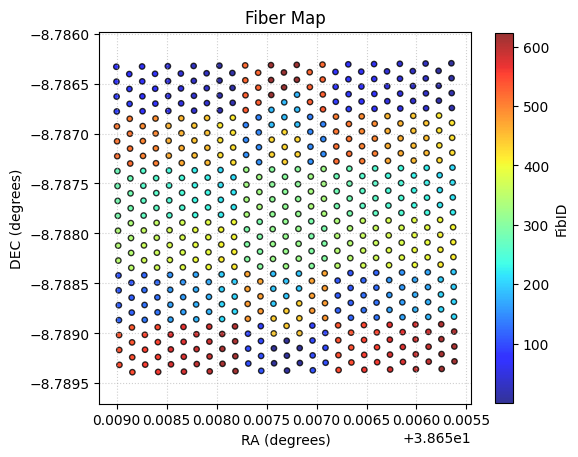

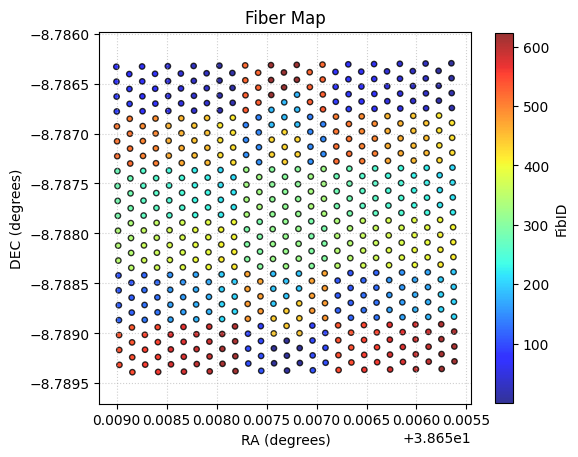

In [130]:
mgcube.megmap_ifu(reduxL,nameF=name,errors=False,flu16=True,spec_range=(None,None),headerInfo={},verbose=True,scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,dtheta_ipa=dtheta_ipa,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],
    facT=[0,1])

In [131]:
file='megCube-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

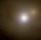

In [132]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

In [133]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985_LR-B.fits.gz
MEGARA/NGC985/megCube-NGC985_LR-B_gri.fits
x_0= 23.2 y_0= 21.6 sigma_0= 1.8699999999999999 psf_0= 2.901960429554305
x_1= 23.6 y_1= 21.6 sigma_1= 1.9 psf_1= 2.948515944466941
02h34m37.85224001s -08d47m16.05888834s RA0,DEC0
02h34m37.84279581s -08d47m16.05888819s RA1,DEC1
x_1_sk= 23.20000000010694 y_1_sk= 21.599999999943623
Dx= -0.40000000000000213 0.3999999998930619
Dy= 0.0 5.637801336888515e-11


### Global astrometric correction

Although the individual observations are internally aligned, the combined
cube may still exhibit a global displacement with respect to the external
reference frame.

For the combined reconstruction, a residual offset of approximately

- -0.4 pixels in X,
- 0.0 pixels in Y

is detected.

This global shift is corrected using the `dx` and `dy` parameters of the
reconstruction routine.

## 12. Final astrometric solution

The global correction is applied directly during the cube reconstruction:

```python
dx=-0.4
dy=0.05
```
After rebuilding the cube and reprojecting the reference imaging, the
measured centroids agree to numerical precision.

The final WCS residuals are approximately 10^-11 pixels, demonstrating
that the reconstructed MEGARA cube is astrometrically aligned with the
external imaging reference.

In [134]:
mgcube.megmap_ifu(reduxL,nameF=name,errors=False,flu16=True,spec_range=(None,None),headerInfo={},scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megCube-NAME.fits',dtheta_ipa=dtheta_ipa,
    dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[0,1],dx=-0.4,dy=0.05)

Processing NGC985
Processing NGC985


In [135]:
file='megCube-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

In [136]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2)

MEGARA/NGC985/megCube-NGC985_LR-B.fits.gz
MEGARA/NGC985/megCube-NGC985_LR-B_gri.fits
x_0= 23.2 y_0= 21.6 sigma_0= 1.8699999999999999 psf_0= 2.901960429554305
x_1= 23.2 y_1= 21.6 sigma_1= 1.9 psf_1= 2.948515944466941
02h34m37.84279581s -08d47m16.07638819s RA0,DEC0
02h34m37.84279581s -08d47m16.07638819s RA1,DEC1
x_1_sk= 23.200000000127652 y_1_sk= 21.59999999980642
Dx= 0.0 -1.276525551929808e-10
Dy= 0.0 1.935802629304817e-10


## 13. Final reconstructed 2D map

The same astrometric solution can be applied when generating a final
two-dimensional reconstructed map.

The resulting map is reprojected against the same external imaging and
validated with `astromatch`.

The final comparison again gives residuals consistent with zero, showing
that the astrometric solution is preserved in both the reconstructed
spectral cube and the derived 2D map.

In [137]:
mgmap.meggen_map(reduxL,savefile=True,nameF=name+'_'+vph,errors=False,flu16=True,spec_range=(None,None),scfx=scfx,
    fac_sizeX=1.0,fac_sizeY=1.0,pix_s=0.35,sigm_s=0.35,alph_s=2.0,out_path=dir1,redux_dir=reduxdir,
    vph=vph,scp=112.36748321030637,basename='final_rss.fits',basenameC='megMap-NAME.fits',dtheta_ipa=dtheta_ipa,
    dxpix=[7.1+1.7,6.6],dypix=[-2.2+0.2,1.0],facT=[0,1],dx=-0.4,dy=0.4)

Processing NGC985
Processing NGC985


In [138]:
file='megMap-NAME_VPH.fits.gz'.replace('NAME',name).replace('VPH',vph)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

2D map


MEGARA/NGC985/megMap-NGC985_LR-B.fits.gz
MEGARA/NGC985/megMap-NGC985_LR-B_gri.fits


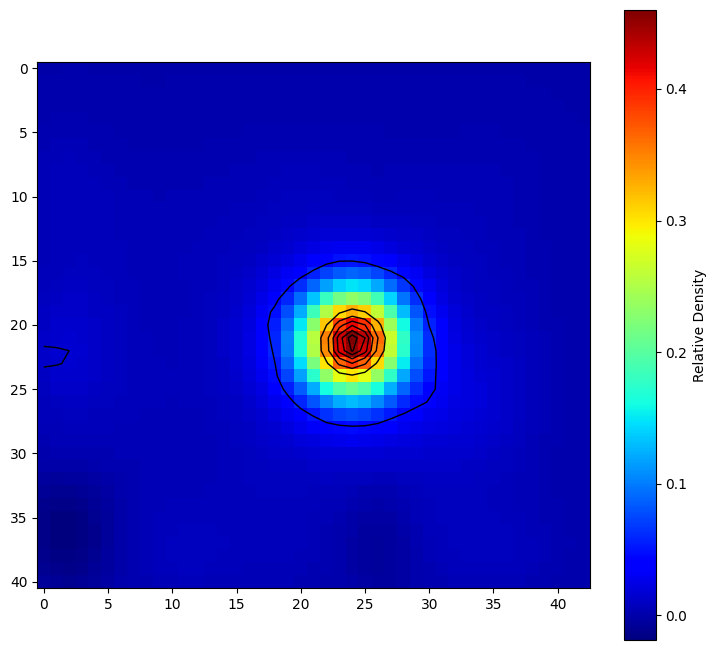

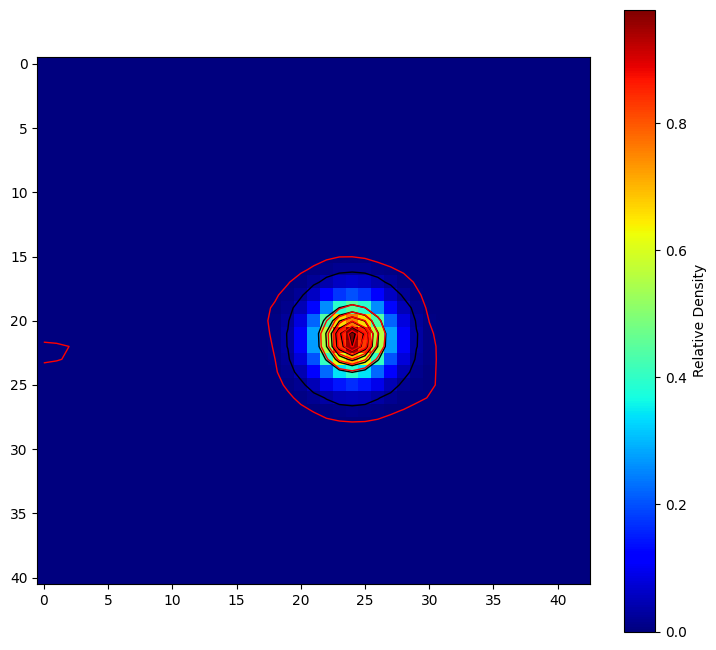

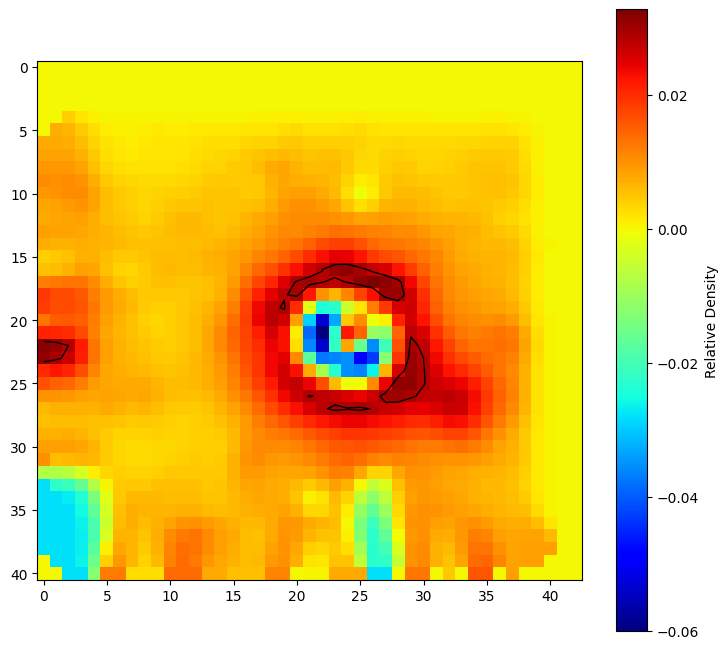

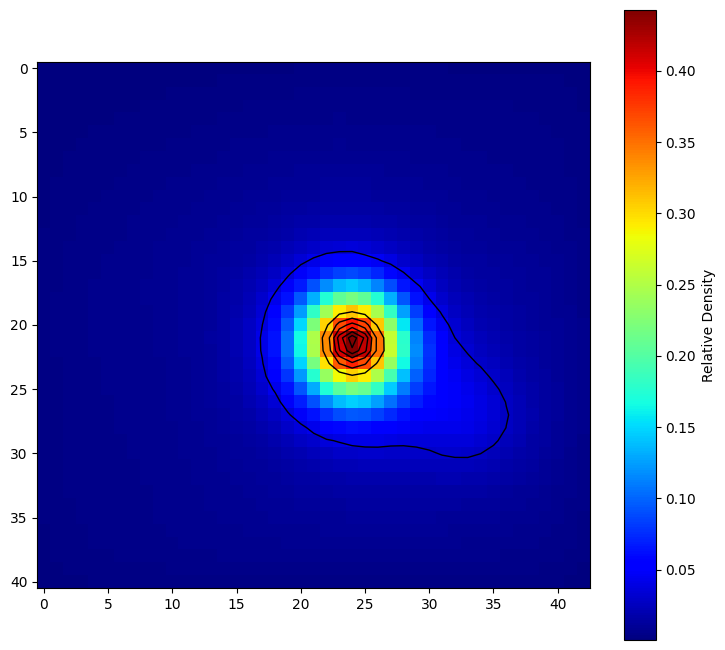

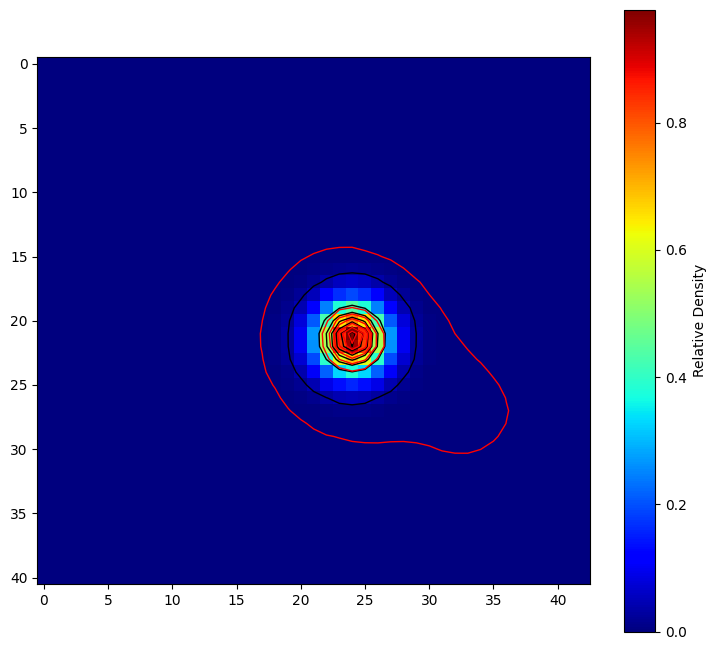

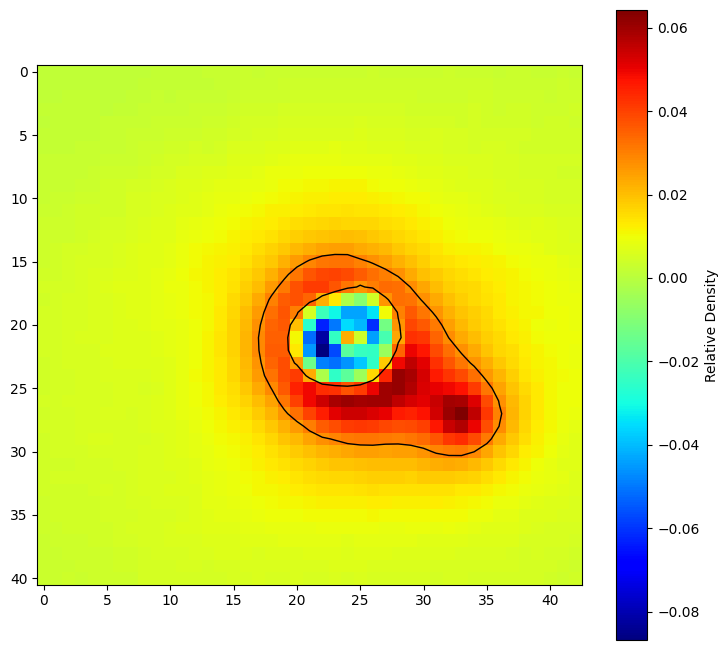

x_0= 24.0 y_0= 21.4 sigma_0= 1.9 psf_0= 2.948515944466941
x_1= 24.0 y_1= 21.4 sigma_1= 1.8699999999999999 psf_1= 2.901960429554305
02h34m37.84235137s -08d47m16.05845295s RA0,DEC0
02h34m37.84235137s -08d47m16.05845295s RA1,DEC1
x_1_sk= 23.999999999970676 y_1_sk= 21.39999999990436
Dx= 0.0 2.9324098704819335e-11
Dy= 0.0 9.563905223330949e-11


In [139]:
file0=dir2+file
file1=dir3+file.replace('.fits.gz','_gri.fits')
valsT=ctools.astromatch(file0,file1,sig=2,plotview=True)

## Summary

This notebook demonstrates an iterative astrometric alignment workflow for
MEGARA data reconstructed with 3DCubeGen.

The procedure can be summarized as:

1. Reconstruct each MEGARA observation.
2. Reproject external imaging onto the IFU spatial grid with `crop_image`.
3. Measure centroid offsets with `astromatch`.
4. Correct individual RSS positions using `dxpix` and `dypix`.
5. Verify the relative registration between multiple observations.
6. Apply any remaining global shift using `dx` and `dy`.
7. Reconstruct the final combined cube and map.
8. Validate the final astrometric solution against the external reference.

For NGC 985, the final reconstructed products reach astrometric residuals
consistent with zero at numerical precision.

> **Note**
>
> `dxpix` and `dypix` correct the relative position of individual RSS
> observations before their combination, whereas `dx` and `dy` apply a
> global shift to the final reconstructed coordinate grid.
>
> In practice, the alignment should therefore be performed in two stages:
> first the relative registration between exposures, and then the absolute
> registration against an external astrometric reference.

# Part IV — Spectral coaddition of LR-B, MR-G, and LR-R

After the three configurations have been reconstructed and placed on a consistent astrometric reference frame, they are combined into a wavelength-continuous cube.

The VPH list must be ordered from shorter to longer wavelength:

```python
['LR-B', 'MR-G', 'LR-R']
```

`coad_cube` uses the celestial WCS of the first available cube as the reference spatial grid, transforms the corresponding sky positions into the other cubes, resamples the spectra onto a common wavelength grid, and combines the overlapping wavelength regions. With `patch=True`, the matching-factor map used in the overlap correction is also written to disk.

The expected input products are:

- `megCube-NGC985_LR-B.fits.gz`
- `megCube-NGC985_MR-G.fits.gz`
- `megCube-NGC985_LR-R.fits.gz`

and the principal output is the final coadded cube `megCube-NGC985.fits.gz`.


In [140]:
vphs = ['LR-B', 'MR-G', 'LR-R']

basenameC = 'megCube-NAME'.replace('NAME', name)

ctools.coad_cube(
    basenameC,
    dir1=dir1,
    dir2=dir2,
    vphs=vphs,
    patch=True,
    verbose=False,
    pbars=True,
    notebook=True,
)

  0%|          | 0/40 [00:00<?, ?it/s]

In [141]:
file='megCube-NAME.fits.gz'.replace('NAME',name)
names = sdss_images
ctools.crop_image(names,file,dir1=dir1+name+'/',dir2=dir2,dir3=dir3)

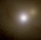

In [142]:
fileI=dir3+file.replace('.fits.gz','_gri.jpeg')
Image(fileI,width=600)

## Final products and validation

The final coaddition should only be performed after the three input cubes have passed their astrometric checks. A useful final validation is to inspect narrow- or broad-band collapses from each wavelength region and verify that the same astronomical structures remain registered across LR-B, MR-G, and LR-R.

For debugging spatial registration, remember the two coordinate conventions used by the workflow:

```text
NumPy cube indexing:       cube[wavelength, y, x]
Astropy celestial WCS:     pixel_to_skycoord(x, y, wcs)
                           skycoord_to_pixel(...) -> (x, y)
```

Keeping this distinction explicit prevents an X/Y interchange when moving between WCS coordinates and NumPy array indices.


## Workflow summary

The complete reduction sequence is therefore:

1. Define the target, data paths, external reference images, and VPH.
2. Reconstruct each individual RSS observation.
3. Reproject the SDSS imaging onto the reconstructed MEGARA grid.
4. Measure the absolute astrometric residuals with `astromatch`.
5. Refine the per-observation `dxpix` and `dypix` corrections.
6. Align the individual observations with one another.
7. Apply any remaining global `dx` and `dy` correction.
8. Repeat the procedure independently for LR-R, MR-G, and LR-B.
9. For MR-G, retain the additional `dtheta_ipa = 105.09°` rotation and `scfx = 1.3` X-axis stretch used by this dataset.
10. Coadd the final aligned VPH cubes with `coad_cube`.

The numerical shifts in this notebook document the NGC 985 reduction and should be regarded as dataset-specific calibration values, not universal MEGARA defaults.
